# Week 9 - Introduction to Neural Networks

**Darren Lim**

### Aims

The main concepts covered in this notebook are: 

>* getting familiar with the basics of keras
>* input-output with keras
>* construction of neural network models with keras

This week, we will be exploring the basics of keras and building and fitting our first neural network with keras. For a quick introduction, please see https://keras.io/getting_started/intro_to_keras_for_engineers/

When completing worksheets:

>- You will have tasks tagged by (CORE) and (EXTRA). 
>- Your primary aim is to complete the (CORE) components during the WS session, afterwards you can try to complete the (EXTRA) tasks for your self-learning process. 

Instructions for submitting your workshops can be found at the end of worksheet. As a reminder, you must submit a pdf of your notebook on Learn by 16:00 PM on the Friday of the week the workshop was given.

# Setup <a id='setup'></a>

## Packages

Let's load the some of the packages needed for this workshop. 

In [1]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns

I0000 00:00:1773853985.493422  124774 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773853985.495074  124774 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773853985.557909  124774 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773853986.863753  124774 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

# Part 1: Simulated Data

In the first part of this workshop, we will work with a simple simulated example to gain some basic understanding of neural networks and keras.

We generate $N=2000$ simulated data points. First we generate the labels assuming that:
$$  y_i \sim \text{Bern}(0.5).$$
Next, we generate the features of dimension $D=2$. The first feature is simulated uniformly in $[-\pi,\pi]$
$$x_{i,1} \sim \text{Uniform}(-\pi,\pi).$$
For the second feature, if $y=0$, then
$$x_{i,2} \sim \text{Norm}(\cos( x_{i,1}),\sigma^2).$$
Otherwise, if $y=1$, then
$$x_{i,2} \sim  \text{Norm}(1+ \cos( x_{i,1}),\sigma^2).$$

In [2]:
# Generate data
keras.utils.set_random_seed(11205)
N = 2000
D = 2
y = np.random.binomial(1, 0.5, N)
X = np.zeros((N, D))
X[:,0] = np.random.uniform(-np.pi, np.pi, N)
X[y == 0,1] = np.cos(X[y == 0,0]) + np.random.normal(0, 0.25, (y == 0).sum())
X[y == 1,1] = 1 + np.cos(X[y == 1,0]) + np.random.normal(0, 0.25, (y == 1).sum())

### 🚩 Exercise 1 (CORE)

Plot the data colored by the class labels. 

**EXTRA.** Derive the true decision boundary and add it to the plot. 

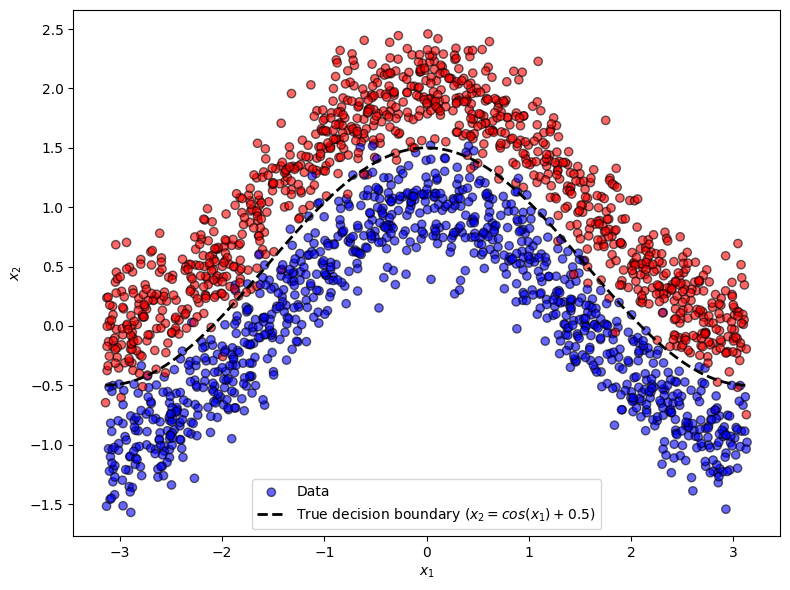

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', alpha=0.6, label='Data')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')

# The boundary is where P(y=1|x) = P(y=0|x).
# Since P(y=0)=P(y=1)=0.5, we need:
#   N(x2; 1+cos(x1), sigma^2) = N(x2; cos(x1), sigma^2)
# Expanding: (x2 - cos(x1))^2 = (x2 - 1 - cos(x1))^2
# Solving: x2 = cos(x1) + 0.5
x1_line = np.linspace(-np.pi, np.pi, 300)
x2_boundary = np.cos(x1_line) + 0.5
ax.plot(x1_line, x2_boundary, 'k--', linewidth=2, label='True decision boundary ($x_2 = cos(x_1)+0.5$)')
ax.legend()
plt.tight_layout()
plt.show()

Q1)

Decision boundary is where a new obervation us equally likely to belong to either class. Hence, P(y=0) = P(y=1) = 0.5, where both class-conditional densities are Gaussian in $x_2$ with the same variance $\sigma^2=0.0625$, but different means:

- Class 0: $\mu_0=cos(x_1)$
- Class 1: $\mu_1=1+cos(x_1)$

Setting the log-likelihoods equal and simpifying gives:

$$x_2=cos(x_1)+0.5$$

This gives a cosine curve shifted up by 0.5 as the true decision boundary.

## Building a baseline logistic regression in keras

Let's start by building a logistic regression model in keras, using the `Functional` model: https://keras.io/guides/functional_api/ 

A `Functional` model provides a way to build a directed graph of `Layers` that connect to each other. `Layers` are the basic building blocks of neural networks in keras:  https://keras.io/api/layers/

To construct a logistic regression model, we only need two layers: 
- an input layer, which we construct using an `Input` layer: https://keras.io/api/layers/core_layers/input/ 
- an output layer, which we construct using a `Dense` layer: https://keras.io/api/layers/core_layers/dense/

In [4]:
# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
logit_layer = keras.layers.Dense(1, activation='sigmoid')

Then, we combine the layers and create our model which connects the input and output. 

In [5]:
output = logit_layer(input_layer)
model_lr = keras.models.Model(input_layer, output)
model_lr.summary()

E0000 00:00:1773853988.348209  124774 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Print the number of layers in the model
print(len(model_lr.layers)) 

2


Alternatively, we can build the model using the `Sequential` model, see https://keras.io/api/models/sequential/ and https://keras.io/guides/sequential_model/. A `Sequential` model is esssentially a plain stack of `Layers` where each layer has exactly one input tensor and one output tensor, while a `Functional` model allows more general constructions (i.e. a graph of layers). 

In [7]:
model_lr2 = keras.Sequential(
    [
        keras.Input(shape=(D,)),
        keras.layers.Dense(1, activation='sigmoid'),
    ]
)
model_lr2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Now, we are ready to compile the model: https://keras.io/api/models/model_training_apis/

When compiling, we need to specify:
- a loss function: https://keras.io/api/losses/
- an optimizer: https://keras.io/api/optimizers/
- (optionally) metrics: https://keras.io/api/metrics/

In [8]:
model_lr.compile(
    loss='binary_crossentropy', # or loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer='adam', # or  optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
       keras.metrics.BinaryAccuracy(name='accuracy'),
       keras.metrics.AUC(name='auc')
    ],
)

### Training the model

Now, we are ready to to fit the model! We need to specifiy: 
- the number of `epochs` (which is the number of times that we cycle through the whole training data during gradient descent), 

and optionally various other parameters, such as 

- `shuffle` (e.g. `shuffle=True`), which specifies whether to shuffle the training data before each epoch.
- `validation_split` which is a float between 0 and 1, determining the fraction of the training data to be used as validation data. The model will set apart this fraction of the training data, will not train on it, and will evaluate the loss and any model metrics on this data at the end of each epoch. This is useful for **early stopping**, i.e. determining if training should be stopped early to prevent overfitting.
- `batch_size`: Integer or None. Number of samples per gradient update. If unspecified, batch_size will default to 32. 
For more details, see: https://keras.io/api/models/model_training_apis/

**Caution:** the data is not shuffled before splitting the data into a validation set. If the data are ordered in particular way when stored, then the training and validation sets can potentially characterize different populations. Thus, it is recommend to first shuffle the order of your data before fitting.  

In [9]:
# If you need to shuffle the data before fitting uncomment the following lines
from sklearn.utils import shuffle
X, y = shuffle(X, y, random_state=11205)

In [10]:
model_lr.fit(x=X, y=y, epochs=50, shuffle=True, validation_split=0.1)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5222 - auc: 0.5473 - loss: 0.8681 - val_accuracy: 0.5750 - val_auc: 0.6248 - val_loss: 0.7708
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5267 - auc: 0.5660 - loss: 0.8305 - val_accuracy: 0.5900 - val_auc: 0.6436 - val_loss: 0.7413
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5322 - auc: 0.5891 - loss: 0.7958 - val_accuracy: 0.5900 - val_auc: 0.6636 - val_loss: 0.7142
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5333 - auc: 0.6181 - loss: 0.7638 - val_accuracy: 0.5950 - val_auc: 0.6878 - val_loss: 0.6896
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5389 - auc: 0.6503 - loss: 0.7346 - val_accuracy: 0.5950 - val_auc: 0.7093 - val_loss: 0.6675
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5417 - auc: 0.6808 - loss: 0.7082 - val_accuracy: 0.5950 - val_auc: 0.7300 - val_loss: 0.6477
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - 

Let's plot the metrics as a function of the number of epochs.

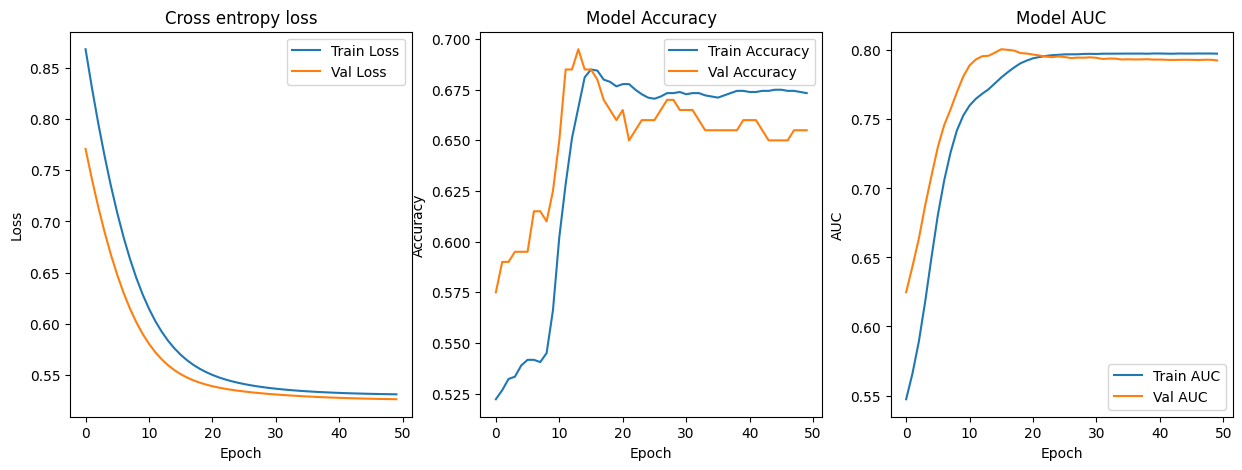

In [11]:
# Plot the training history
history = model_lr.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_title('Cross entropy loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[1].plot(history['accuracy'], label='Train Accuracy')
ax[1].plot(history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[2].plot(history['auc'], label='Train AUC')
ax[2].plot(history['val_auc'], label='Val AUC')
ax[2].set_title('Model AUC')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('AUC')
ax[2].legend()
plt.show()

If you notice that the validation loss (and metrics) is still decreasing (increasing) as a function of epochs, this suggests that you may need to train the model longer.

If you notice that the validation loss (and metrics) starts to increase (decrease) as a function of epochs, this suggests that the model is starting to overfit. Based on this, we can determine the number of epochs to use based on the U-shape of the validation loss (this is known as early stopping, for more info see: https://keras.io/api/callbacks/early_stopping/). 

### Testing the model

Now, we can use `.predict()` to make predictions. Let's predict at a grid of test points and draw a heatmap of the predicted probabilities.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step


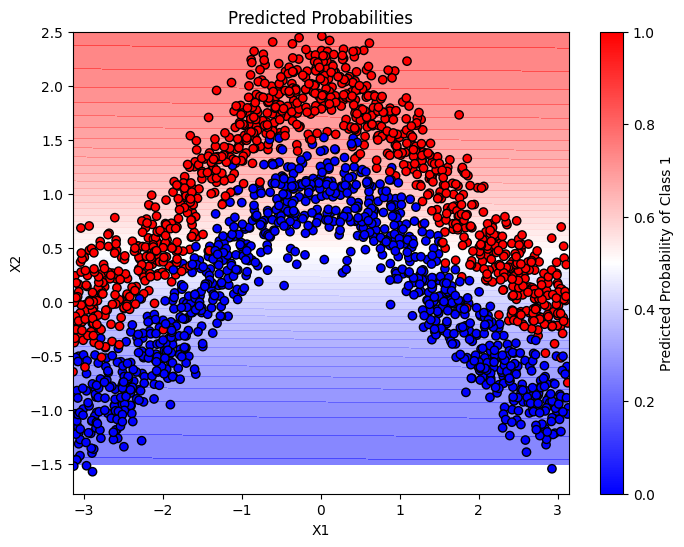

In [12]:
# Create a grid of test points
X_grid1, X_grid2 = np.meshgrid(np.linspace(-np.pi, np.pi, 100), np.linspace(-1.5, 2.5, 100))
X_grid = np.column_stack([X_grid1.ravel(), X_grid2.ravel()])

# Predict probabilities 
y_pred_prob_lr = model_lr.predict(X_grid)

# Draw a heatmap of the predicted probabilities
plt.figure(figsize=(8, 6))
plt.contourf(X_grid1, X_grid2, y_pred_prob_lr.reshape(X_grid1.shape), levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Predicted Probabilities')
plt.colorbar(label='Predicted Probability of Class 1')
plt.show()

### 🚩 Exercise 2 (CORE)

- Generate 1000 test data points from the same data generating process used to generated the training data.
- Compute the `classification_report` and `confusion_matrix`
- Is the result what you expect, and why?

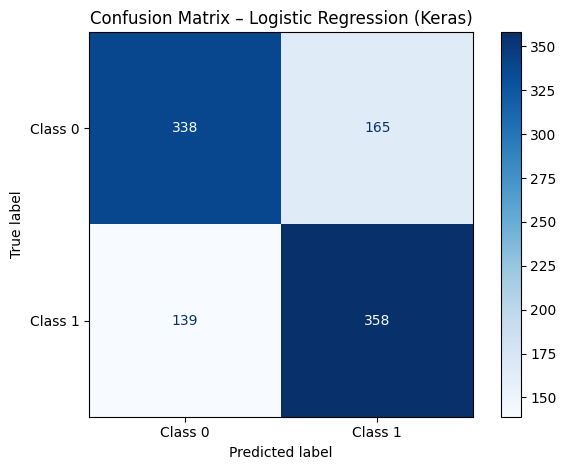

              precision    recall  f1-score   support

     Class 0       0.71      0.67      0.69       503
     Class 1       0.68      0.72      0.70       497

    accuracy                           0.70      1000
   macro avg       0.70      0.70      0.70      1000
weighted avg       0.70      0.70      0.70      1000



In [13]:
# Code for your answer here!
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
N_test = 1000
y_test_sim = np.random.binomial(1, 0.5, N_test)
X_test_sim = np.zeros((N_test, D))
X_test_sim[:, 0] = np.random.uniform(-np.pi, np.pi, N_test)
X_test_sim[y_test_sim == 0, 1] = (np.cos(X_test_sim[y_test_sim == 0, 0]) +
                                   np.random.normal(0, 0.25, (y_test_sim == 0).sum()))
X_test_sim[y_test_sim == 1, 1] = (1 + np.cos(X_test_sim[y_test_sim == 1, 0]) +
                                   np.random.normal(0, 0.25, (y_test_sim == 1).sum()))

# Predict with logistic regression model
y_pred_prob = model_lr.predict(X_test_sim, verbose=0).ravel()
y_pred_class = (y_pred_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test_sim, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Logistic Regression (Keras)')
plt.tight_layout()
plt.show()

# Classification report
print(classification_report(y_test_sim, y_pred_class, target_names=['Class 0', 'Class 1']))


Q2)

The logistic regression model achieves ~70% accuracy. This is expected as logistic regression can only learn a linear decision boundary in feature space, while the true decision boundary is the non-linear curve $x_2=cos(x_1)+0.5$. Hence, there will always be a systematic misclassification error for a linear model on this dataset.

### Adding a hidden layer

Now, let's add a hidden layer, with 2 neurons.

In [14]:
input_layer = keras.Input(shape=(D,))
hidden_layer = keras.layers.Dense(2, activation='relu')(input_layer)
output_layer = keras.layers.Dense(1, activation='sigmoid')(hidden_layer)
model_hidden2 = keras.Model(inputs=input_layer, outputs=output_layer)
model_hidden2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

### 🚩 Exercise 3 (CORE)

Compile the model, train and plot the metrics as a function of epochs. 

Continue to train the model for more epochs as needed. Note: rerun the fit line will continue to train the model from where it left off.

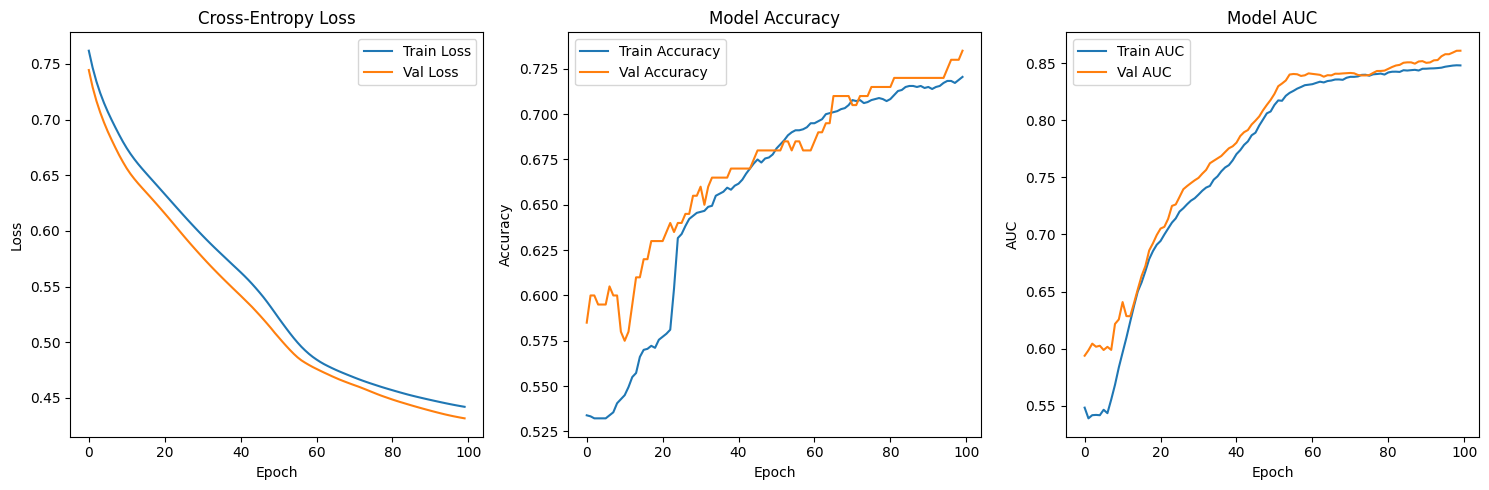

In [15]:
model_hidden2.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.AUC(name='auc'),
    ],
)

history_h2 = model_hidden2.fit(
    x=X, y=y,
    epochs=100,
    batch_size=64,
    shuffle=True,
    validation_split=0.1,
    verbose=0,
)

# Plot training history
hist = history_h2.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(hist['loss'], label='Train Loss')
ax[0].plot(hist['val_loss'], label='Val Loss')
ax[0].set_title('Cross-Entropy Loss')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss'); ax[0].legend()
ax[1].plot(hist['accuracy'], label='Train Accuracy')
ax[1].plot(hist['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy'); ax[1].legend()
ax[2].plot(hist['auc'], label='Train AUC')
ax[2].plot(hist['val_auc'], label='Val AUC')
ax[2].set_title('Model AUC')
ax[2].set_xlabel('Epoch'); ax[2].set_ylabel('AUC'); ax[2].legend()
plt.tight_layout()
plt.show()

### 🚩 Exercise 4 (CORE)

Draw a heatmap of the predicted probabilities. How does the model perform now?

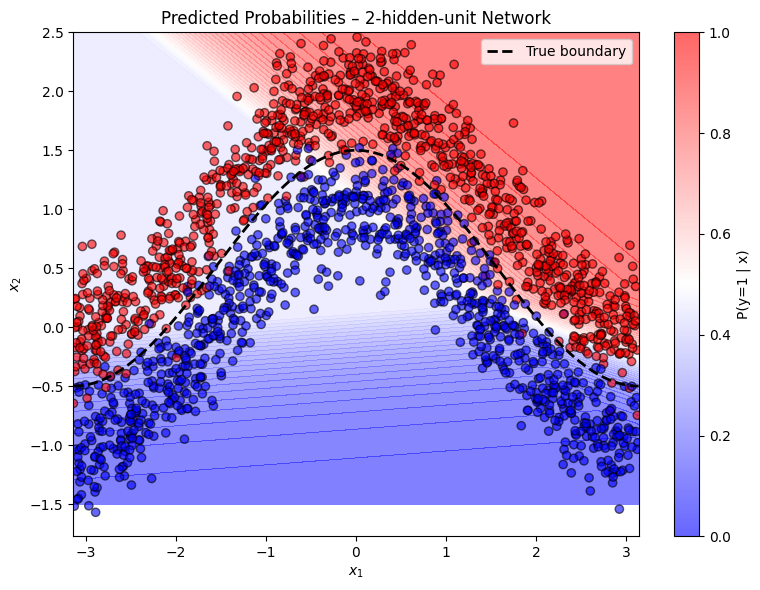

In [16]:
y_pred_prob_h2 = model_hidden2.predict(X_grid, verbose=0)

plt.figure(figsize=(8, 6))
plt.contourf(X_grid1, X_grid2, y_pred_prob_h2.reshape(X_grid1.shape),
             levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', alpha=0.6)
# True decision boundary
x1_line = np.linspace(-np.pi, np.pi, 300)
plt.plot(x1_line, np.cos(x1_line) + 0.5, 'k--', linewidth=2,
         label='True boundary')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Predicted Probabilities – 2-hidden-unit Network')
plt.colorbar(label='P(y=1 | x)')
plt.legend()
plt.tight_layout()
plt.show()

Q4)

With only 2 hidden ReLU units, the network produces a piecewise-linear decision boundary. Compared to the logistic regression model (purely linear boundary), the 2-unit network shows a curved boundary that partially tracks the cosone shape, but two units are still insufficient to closely follow the true boundary $x_2=cos(x_1)+0.5$. Hence, accuracy improves, but it is still insufficient.

### Visualizing the output of each neuron

By visualizing the output of each neuron, we can gain an understanding of the features extracted. 

In the code below, we create a keras model for the mapping of the inputs to the hidden layer and pass through the data. By plotting the output of the hidden layer, we observe that:
- the first hidden feature captures the separation of the two classes when $x_1<0$ and 
- the second hidden feature captures the separation of the two classes when $x_1>0$.

In [17]:
# Extract the output of the hidden layer
hidden_layer_model = keras.Model(inputs=model_hidden2.input, outputs=model_hidden2.layers[1].output)

# Hidden output for the observed data
z =hidden_layer_model(X)
# Convert to numpy array
z = z.numpy()

# Hidden output for the test points
z_grid =hidden_layer_model(X_grid)
# Convert to numpy array
z_grid = z_grid.numpy()

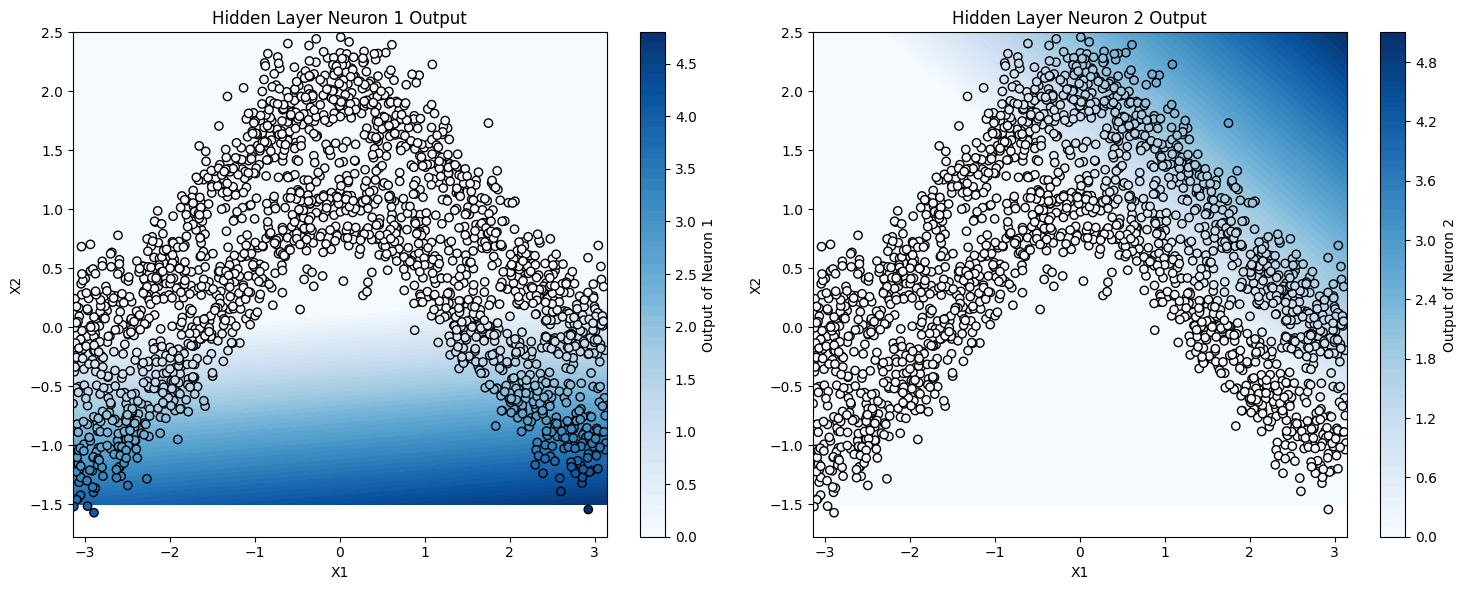

In [18]:
# Draw a heatmap of the output of the hidden layer neurons
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for i in range(2):
    vmin= min(z[:,i].min(), z_grid[:,i].min())   
    vmax= max(z[:,i].max(), z_grid[:,i].max())
    ax[i].contourf(X_grid1, X_grid2, z_grid[:,i].reshape(X_grid1.shape), levels=50, cmap='Blues', vmin=vmin, vmax=vmax)
    ax[i].scatter(X[:,0], X[:,1], c=z[:,i], cmap='Blues', edgecolor='k',vmin=vmin, vmax=vmax)
    ax[i].set_xlabel('X1')
    ax[i].set_ylabel('X2')
    ax[i].set_title(f'Hidden Layer Neuron {i+1} Output')
    cbar = plt.colorbar(ax[i].collections[0], ax=ax[i])
    cbar.set_label(f'Output of Neuron {i+1}')
fig.tight_layout() 
plt.show()

We can also print out the values of the weights and bias for each layer:

In [19]:
print('Hidden layer bias:', model_hidden2.layers[1].bias.numpy())
print('Hidden layer weights:', model_hidden2.layers[1].kernel.numpy())
print('Output layer bias:', model_hidden2.layers[2].bias.numpy())
print('Output layer weights:', model_hidden2.layers[2].kernel.numpy())

Hidden layer bias: [ 0.35218954 -1.4534887 ]
Hidden layer weights: [[ 0.15483356  0.91698444]
 [-2.634534    1.4607444 ]]
Output layer bias: [-0.25475878]
Output layer weights: [[-1.1116455]
 [ 1.8593135]]


### Increasing the width of the network

### 🚩 Exercise 5 (CORE)

Now, try increasing the number of hidden units to 5.
- Define and compile the model.
- Fit the model and train for as many epochs find are needed.
- Draw a heatmap of the predicted probabilities over the grid of input values.
- Draw heatmaps of the output for each hidden unit over the grid of input values.

Comment on how the predictions have changed and what features appear to be extracted by each hidden unit. Which model would you choose and why?

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

Final val accuracy: 0.9750


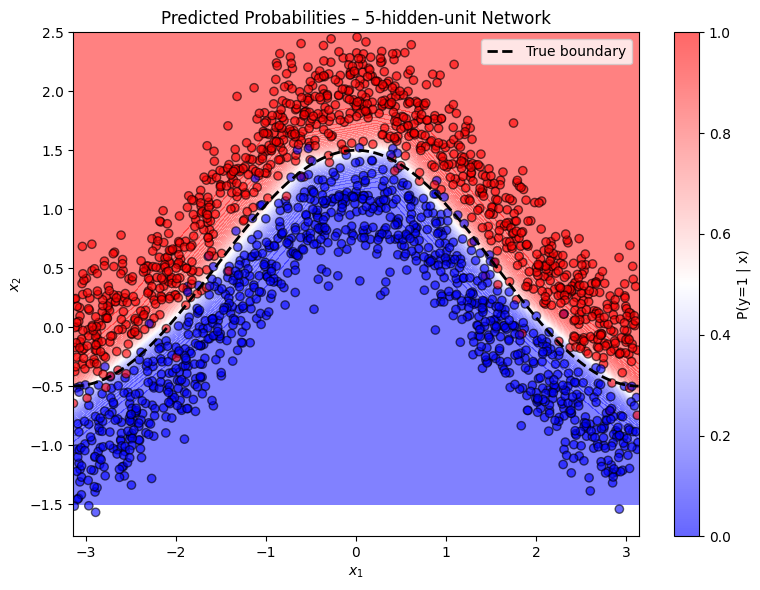

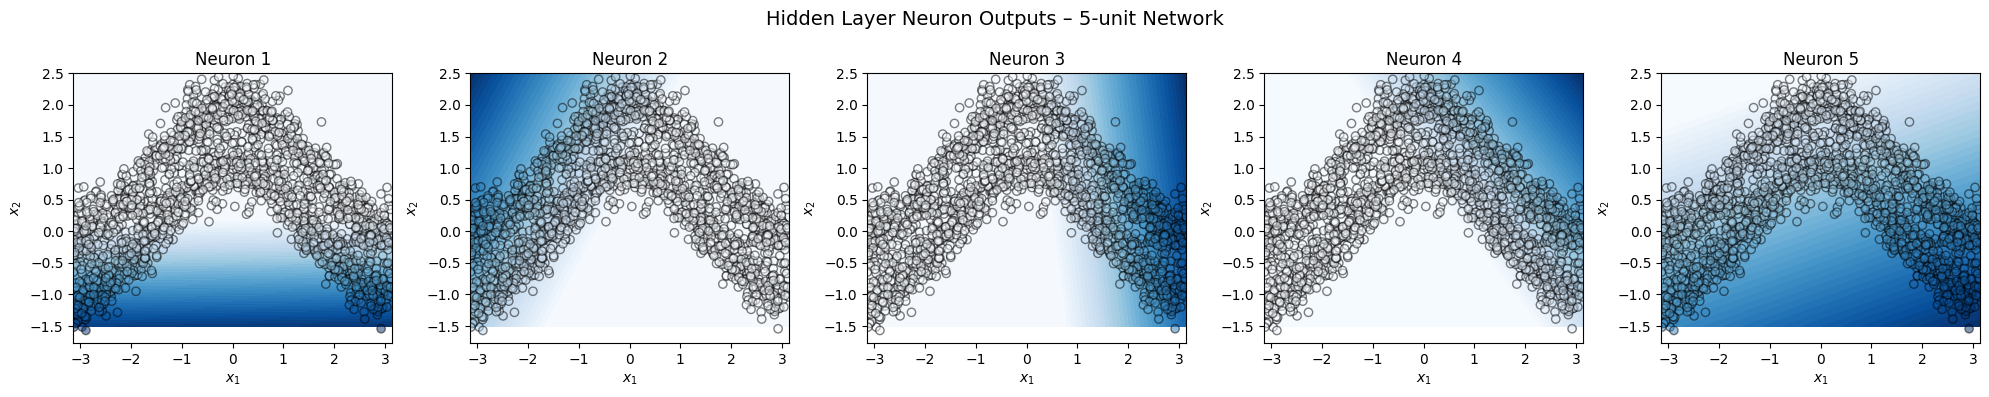

In [20]:
input_layer = keras.Input(shape=(D,))
hidden_layer5 = keras.layers.Dense(5, activation='relu')(input_layer)
output_layer5 = keras.layers.Dense(1, activation='sigmoid')(hidden_layer5)
model_hidden5 = keras.Model(inputs=input_layer, outputs=output_layer5)
model_hidden5.summary()

model_hidden5.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy'),
             keras.metrics.AUC(name='auc')],
)

history_h5 = model_hidden5.fit(
    x=X, y=y,
    epochs=150,
    batch_size=64,
    shuffle=True,
    validation_split=0.1,
    verbose=0,
)

print(f"Final val accuracy: {history_h5.history['val_accuracy'][-1]:.4f}")

# Heatmap of predicted probabilities
y_pred_prob_h5 = model_hidden5.predict(X_grid, verbose=0)
plt.figure(figsize=(8, 6))
plt.contourf(X_grid1, X_grid2, y_pred_prob_h5.reshape(X_grid1.shape),
             levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', alpha=0.6)
x1_line = np.linspace(-np.pi, np.pi, 300)
plt.plot(x1_line, np.cos(x1_line) + 0.5, 'k--', linewidth=2, label='True boundary')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Predicted Probabilities – 5-hidden-unit Network')
plt.colorbar(label='P(y=1 | x)')
plt.legend()
plt.tight_layout()
plt.show()

# Heatmap of each hidden unit's output
hidden_model5 = keras.Model(inputs=model_hidden5.input,
                             outputs=model_hidden5.layers[1].output)
z5 = hidden_model5.predict(X, verbose=0)
z5_grid = hidden_model5.predict(X_grid, verbose=0)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    vmin = min(z5[:, i].min(), z5_grid[:, i].min())
    vmax = max(z5[:, i].max(), z5_grid[:, i].max())
    axes[i].contourf(X_grid1, X_grid2, z5_grid[:, i].reshape(X_grid1.shape),
                     levels=50, cmap='Blues', vmin=vmin, vmax=vmax)
    axes[i].scatter(X[:, 0], X[:, 1], c=z5[:, i], cmap='Blues',
                    edgecolor='k', alpha=0.5, vmin=vmin, vmax=vmax)
    axes[i].set_title(f'Neuron {i+1}')
    axes[i].set_xlabel('$x_1$'); axes[i].set_ylabel('$x_2$')
fig.suptitle('Hidden Layer Neuron Outputs – 5-unit Network', fontsize=14)
plt.tight_layout()
plt.show()

Q5)

With 5 hidden ReLU units the predicted boundary is more flexible and follows the cosine shape more closely than the 2-unit network. Each neuron learns a different half-plane hyperplane cut, and together, they tile the input space and approximate the curved boundary. Looking at the individual neuron heatmaps, each neuron activates over a different region of $(x_1, x_2)$-space, e.g. one neuron may fire for positive $x_1$ when $x_2$ is high, another for negative $x_1$, etc. The output layer then combines these region detectors.

The 5-unit network is preferred over the 2-unit network because it achieves a significantly better approximation of the true non-linear decision boundary, giving a much better accuracy-to-complexity ratio.

### Increasing the depth of the network

### 🚩 Exercise 6 (CORE)

Now, consider a model with two layers: 5 hidden units in the first layer and 2 hidden units in the second layer.
- Define and compile the model.
- Fit the model and train for as many epochs find are needed.
- Draw a heatmap of the predicted probabilities over the grid of input values.
- Draw heatmaps of the output for each hidden unit (in both layers) over the grid of input values.

Comment on how the predictions have changed and differences in the features extracted by the second layer compared to the first. Which model would you choose and why?

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30 (120.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 0 (0.00 B)

Final val accuracy: 0.9700


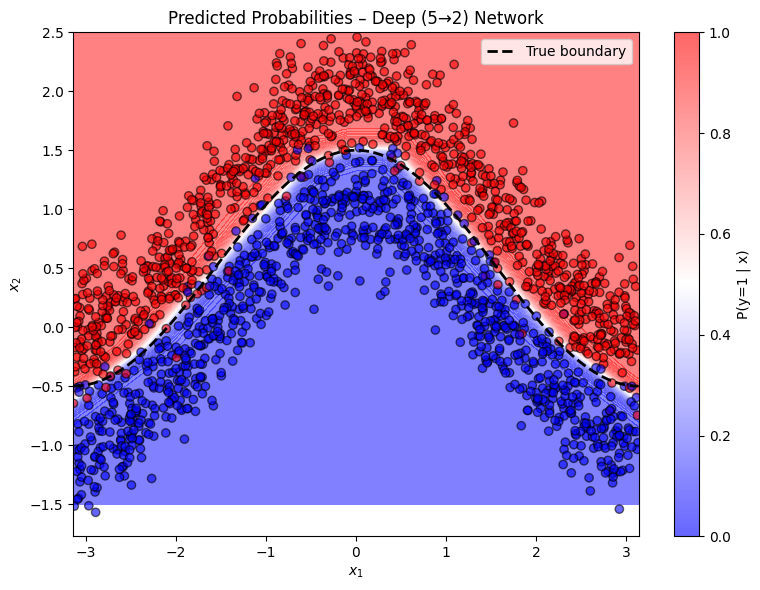

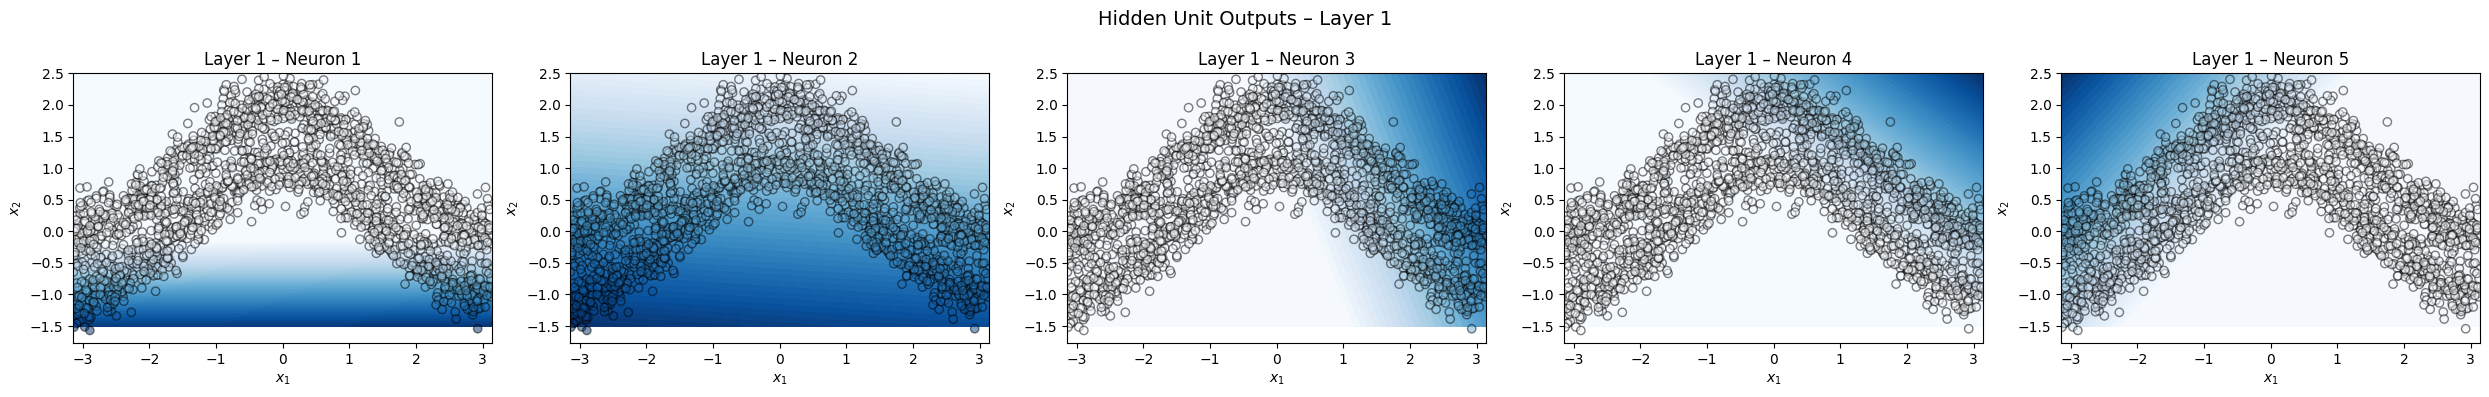

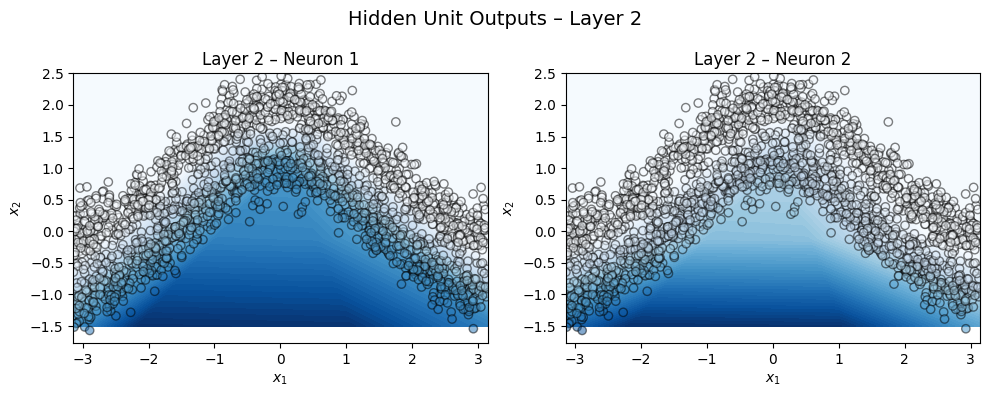

In [21]:
input_layer = keras.Input(shape=(D,))
h1 = keras.layers.Dense(5, activation='relu')(input_layer)
h2 = keras.layers.Dense(2, activation='relu')(h1)
out = keras.layers.Dense(1, activation='sigmoid')(h2)
model_deep = keras.Model(inputs=input_layer, outputs=out)
model_deep.summary()

model_deep.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy'),
             keras.metrics.AUC(name='auc')],
)

history_deep = model_deep.fit(
    x=X, y=y,
    epochs=200,
    batch_size=64,
    shuffle=True,
    validation_split=0.1,
    verbose=0,
)

print(f"Final val accuracy: {history_deep.history['val_accuracy'][-1]:.4f}")

# Heatmap of predicted probabilities
y_pred_prob_deep = model_deep.predict(X_grid, verbose=0)
plt.figure(figsize=(8, 6))
plt.contourf(X_grid1, X_grid2, y_pred_prob_deep.reshape(X_grid1.shape),
             levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', alpha=0.6)
x1_line = np.linspace(-np.pi, np.pi, 300)
plt.plot(x1_line, np.cos(x1_line) + 0.5, 'k--', linewidth=2, label='True boundary')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Predicted Probabilities – Deep (5→2) Network')
plt.colorbar(label='P(y=1 | x)')
plt.legend()
plt.tight_layout()
plt.show()

# Heatmaps of hidden layer outputs (layer 1: 5 units, layer 2: 2 units)
for layer_idx, n_units, layer_name in [(1, 5, 'Layer 1'), (2, 2, 'Layer 2')]:
    hidden_mdl = keras.Model(inputs=model_deep.input,
                              outputs=model_deep.layers[layer_idx].output)
    z_obs  = hidden_mdl.predict(X, verbose=0)
    z_grid = hidden_mdl.predict(X_grid, verbose=0)
    
    fig, axes = plt.subplots(1, n_units, figsize=(5 * n_units, 4))
    if n_units == 1:
        axes = [axes]
    for i in range(n_units):
        vmin = min(z_obs[:, i].min(), z_grid[:, i].min())
        vmax = max(z_obs[:, i].max(), z_grid[:, i].max())
        axes[i].contourf(X_grid1, X_grid2, z_grid[:, i].reshape(X_grid1.shape),
                         levels=50, cmap='Blues', vmin=vmin, vmax=vmax)
        axes[i].scatter(X[:, 0], X[:, 1], c=z_obs[:, i], cmap='Blues',
                        edgecolor='k', alpha=0.5, vmin=vmin, vmax=vmax)
        axes[i].set_title(f'{layer_name} – Neuron {i+1}')
        axes[i].set_xlabel('$x_1$'); axes[i].set_ylabel('$x_2$')
    fig.suptitle(f'Hidden Unit Outputs – {layer_name}', fontsize=14)
    plt.tight_layout()
    plt.show()


Q6)

The two-layer network can learn compositions of linear functions and produce more complex, hierarchical feature representations. The predicted boundary is typically smoother and more closely follows the true cosine curve than the single-layer 5-unit model.


- **Layer 1 (5 units)**: Learns low-level features: half-plane detectors in the raw $(x_1, x_2)$ input space, similar to the single-hidden-layer case.
- **Layer 2 (2 units)**: Learns higher-level combinations of Layer 1's activations, effectively distilling the 5 low-level features into 2 more abstract representations that directly summarise "is the point above or below the boundary?".

The two-layer (5→2) model is preferred over the single 5-unit model because it can learn more expressive representations with the additional depth. However, for this relatively simple 2-D dataset, the gain may be modest and the single-layer 5-unit model may already suffice.

### Changing the activation function

### 🚩 Exercise 7 (EXTRA)

Next, let's explore changing the activation function. 

- Define and compile with your choice of width and depth (number of layers and number of hidden units within each layer), but consider a different activation function for the hidden layer, namely `tanh`.
- Fit the model and train for as many epochs find are needed.
- Draw a heatmap of the predicted probabilities over the grid of input values.
- Draw heatmaps of the output for each hidden unit over the grid of input values.

Comment on how the predictions have changed and differences in the features extracted when using the `tanh` activation function instead of the `relu` activation.

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30 (120.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 0 (0.00 B)

Final val accuracy: 0.9750


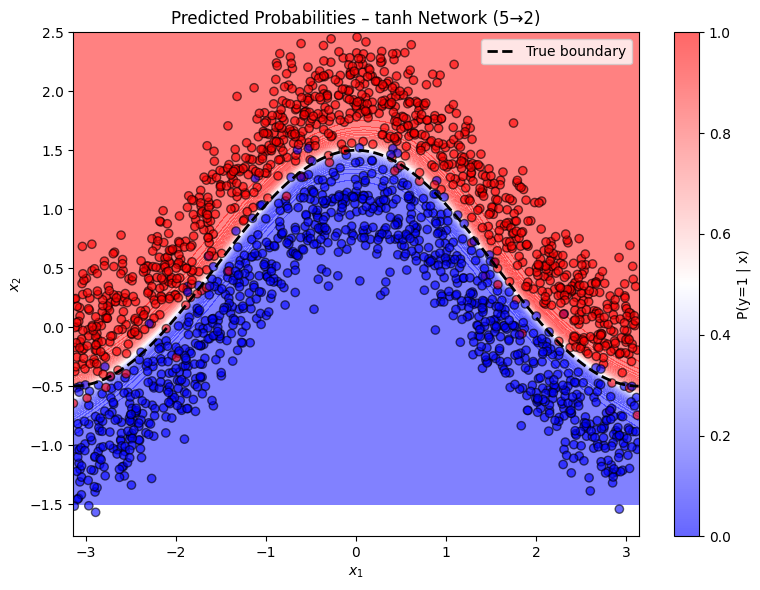

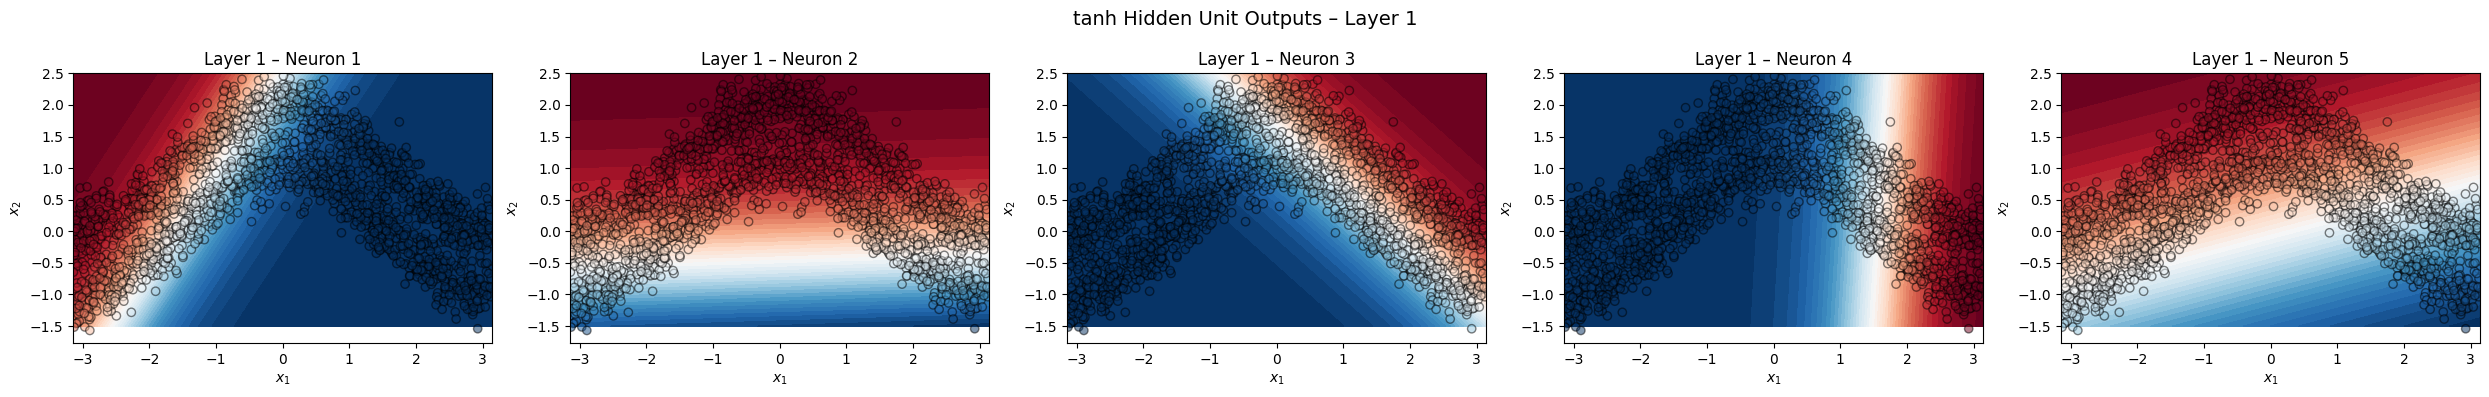

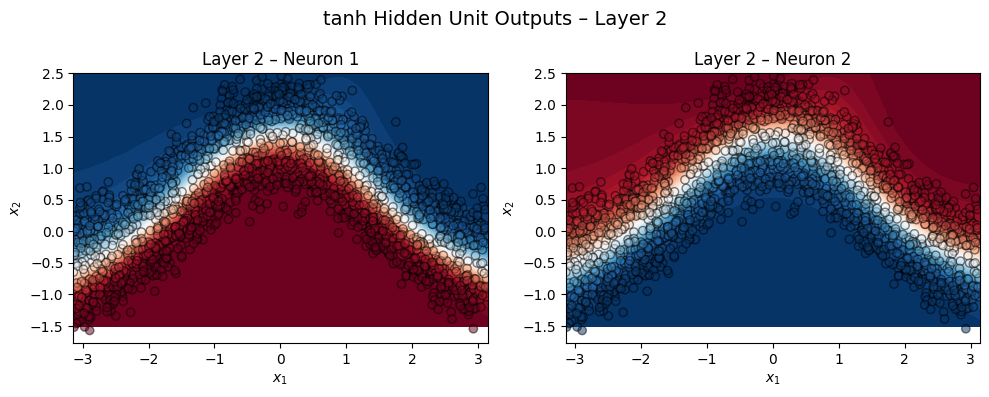

In [22]:
input_layer = keras.Input(shape=(D,))
h1_tanh = keras.layers.Dense(5, activation='tanh')(input_layer)
h2_tanh = keras.layers.Dense(2, activation='tanh')(h1_tanh)
out_tanh = keras.layers.Dense(1, activation='sigmoid')(h2_tanh)
model_tanh = keras.Model(inputs=input_layer, outputs=out_tanh)
model_tanh.summary()

model_tanh.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy'),
             keras.metrics.AUC(name='auc')],
)

history_tanh = model_tanh.fit(
    x=X, y=y,
    epochs=200,
    batch_size=64,
    shuffle=True,
    validation_split=0.1,
    verbose=0,
)

print(f"Final val accuracy: {history_tanh.history['val_accuracy'][-1]:.4f}")

# Predicted probability heatmap
y_pred_prob_tanh = model_tanh.predict(X_grid, verbose=0)
plt.figure(figsize=(8, 6))
plt.contourf(X_grid1, X_grid2, y_pred_prob_tanh.reshape(X_grid1.shape),
             levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', alpha=0.6)
x1_line = np.linspace(-np.pi, np.pi, 300)
plt.plot(x1_line, np.cos(x1_line) + 0.5, 'k--', linewidth=2, label='True boundary')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Predicted Probabilities – tanh Network (5→2)')
plt.colorbar(label='P(y=1 | x)')
plt.legend()
plt.tight_layout()
plt.show()

# Hidden unit heatmaps
for layer_idx, n_units, layer_name in [(1, 5, 'Layer 1'), (2, 2, 'Layer 2')]:
    hidden_mdl_t = keras.Model(inputs=model_tanh.input,
                                outputs=model_tanh.layers[layer_idx].output)
    z_obs  = hidden_mdl_t.predict(X, verbose=0)
    z_grid = hidden_mdl_t.predict(X_grid, verbose=0)
    
    fig, axes = plt.subplots(1, n_units, figsize=(5 * n_units, 4))
    if n_units == 1:
        axes = [axes]
    for i in range(n_units):
        vmin = min(z_obs[:, i].min(), z_grid[:, i].min())
        vmax = max(z_obs[:, i].max(), z_grid[:, i].max())
        axes[i].contourf(X_grid1, X_grid2, z_grid[:, i].reshape(X_grid1.shape),
                         levels=50, cmap='RdBu', vmin=vmin, vmax=vmax)
        axes[i].scatter(X[:, 0], X[:, 1], c=z_obs[:, i], cmap='RdBu',
                        edgecolor='k', alpha=0.5, vmin=vmin, vmax=vmax)
        axes[i].set_title(f'{layer_name} – Neuron {i+1}')
        axes[i].set_xlabel('$x_1$'); axes[i].set_ylabel('$x_2$')
    fig.suptitle(f'tanh Hidden Unit Outputs – {layer_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

Q7)

Visually, the tanh boundary is smoother/more curved while ReLU boundaries are more angular/piecewise linear. In practice, both activations achieve similar accuracy for this dataset.

- **Smoothness**: tanh is a smooth, differentiable function everywhere outputting values in $(-1, 1)$. This means the hidden-unit heatmaps show smooth gradients rather than sharp activation thresholds. The resulting decision boundary is consequently smoother.
- **Symmetry**: tanh is zero-centred, which can lead to faster convergence than ReLU in shallow networks. The hidden-unit outputs can be both positive and negative, allowing each neuron to encode both sides of a feature threshold simultaneously.
- **ReLU by contrast**: Produces sparse activations (many neurons output exactly 0), creating piecewise-constant regions in the feature maps and sharper boundaries.

# Part 2: MNIST Data

### Loading, exploring, and preparing the data

For the second part, we are going to use the MNIST dataset, partly because you are already familiar with it, and partly because it comes with tensorflow, the most widely used library for neural networks in python.

Let's start by load the MNIST data using `keras.datasets.mnist.load_data()`

In [23]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)



Let's display the six images in the training set.

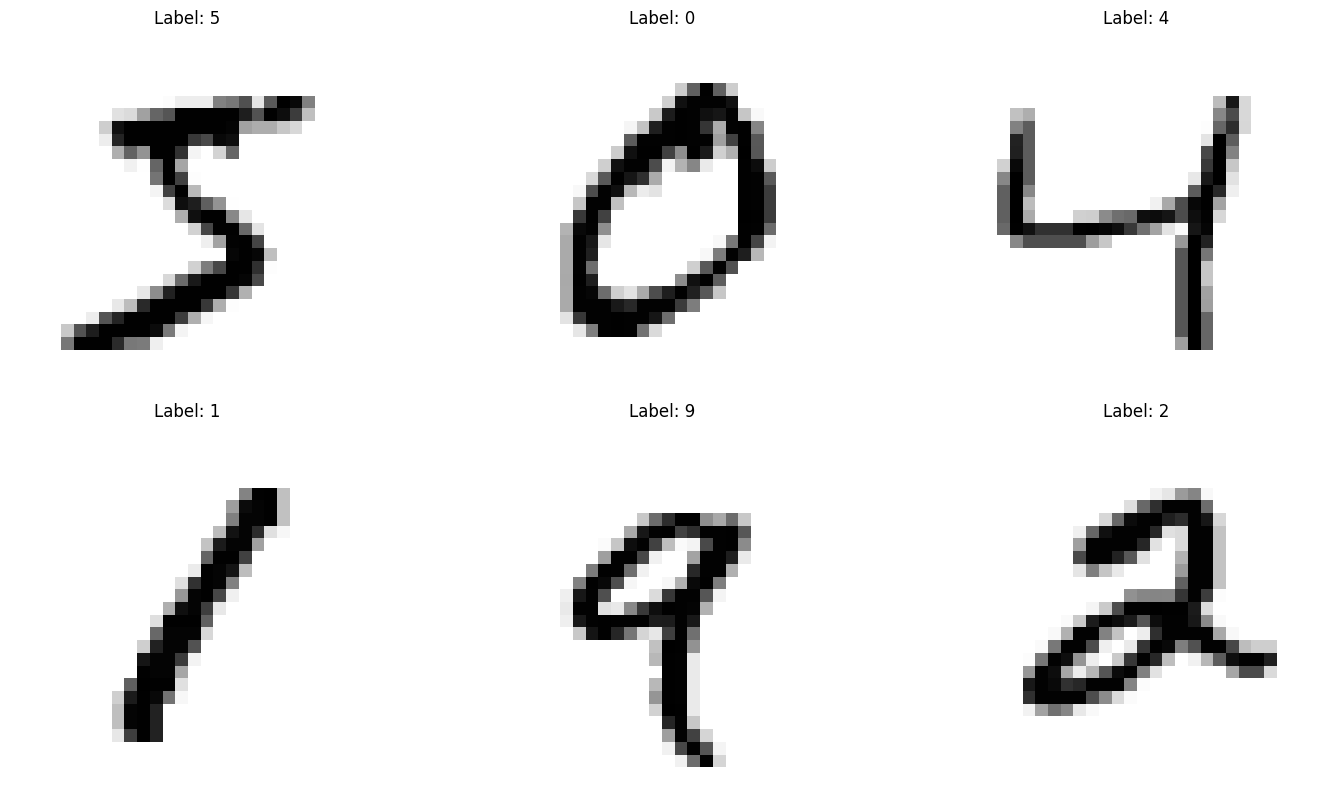

In [24]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax = ax.flatten()
for i in range(6):
    ax[i].imshow(X_train[i], cmap="gray_r")
    ax[i].set_title(f"Label: {y_train[i]}")
    ax[i].axis('off')
fig.tight_layout()
plt.show()

Next, we divide the features by 255 (the maximum value of the pixels), so that all pixel values in the training and testing data are between 0 and 1. 

In the workshop, we will be working only with fully connected feed-forward networks (that don't exploit the spatial structure of the images like convolutional neural networks). As such, we also flatten all images to vectors.

In [25]:
# Rescale the data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape the data 
X_train = X_train.reshape((-1, 28 * 28))
X_test = X_test.reshape((-1, 28 * 28))

Lastly, we use convert the labels using a `LabelEncoder`.

In [26]:
# Converting the labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

### 🚩 Exercise 8 (CORE)

As a baseline model, create a pipeline (called `baseline`) that
- first uses PCA to reduce the dimension to 100
- then uses logistic regression with no penalty

Fit the pipeline to the data. Plot the confusion matrix and print the classification report. How many parameters does the logistic regression model have?

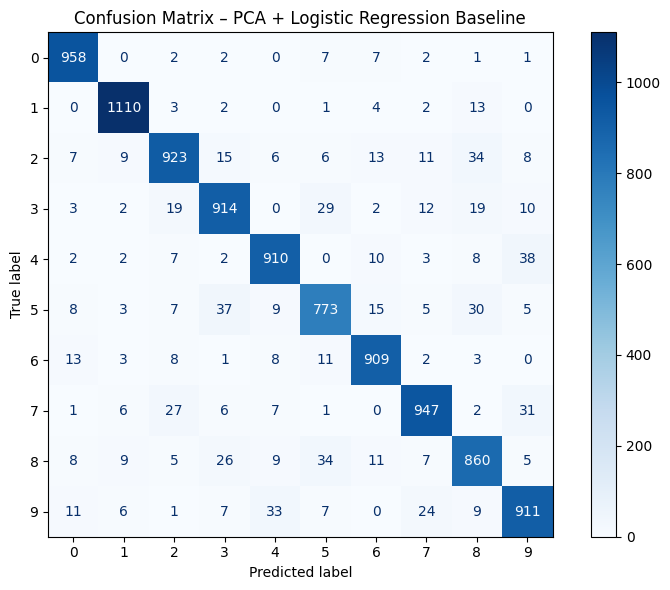

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.97      0.98      0.97      1135
           2       0.92      0.89      0.91      1032
           3       0.90      0.90      0.90      1010
           4       0.93      0.93      0.93       982
           5       0.89      0.87      0.88       892
           6       0.94      0.95      0.94       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.90      0.90      0.90      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

Number of logistic regression parameters: 1010
  Coefficients: (10, 100)  (1000)
  Intercepts:   (10,)  (10)


In [27]:
import warnings 
warnings.filterwarnings('ignore')

from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import log_loss

# Build pipeline: PCA(100) → LogisticRegression (no penalty)
baseline = make_pipeline(
    PCA(n_components=100, random_state=42),
    LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000,
                       multi_class='multinomial', random_state=42)
)

baseline.fit(X_train, y_train)
y_test_pred = baseline.predict(X_test)

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred,
                                         display_labels=label_encoder.classes_,
                                         ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix – PCA + Logistic Regression Baseline')
plt.tight_layout()
plt.show()

# Classification report
print(classification_report(y_test, y_test_pred,
                             target_names=[str(c) for c in label_encoder.classes_]))

# Number of parameters in the logistic regression
lr_model = baseline.named_steps['logisticregression']
n_params = lr_model.coef_.size + lr_model.intercept_.size
print(f"Number of logistic regression parameters: {n_params}")
print(f"  Coefficients: {lr_model.coef_.shape}  ({lr_model.coef_.size})")
print(f"  Intercepts:   {lr_model.intercept_.shape}  ({lr_model.intercept_.size})")


Let's plot some of the images that were both correctly and incorrectly classified, along with the corresponding probabilities. 

Note: if you have called your model something other than `baseline`, please change the name in the code below.

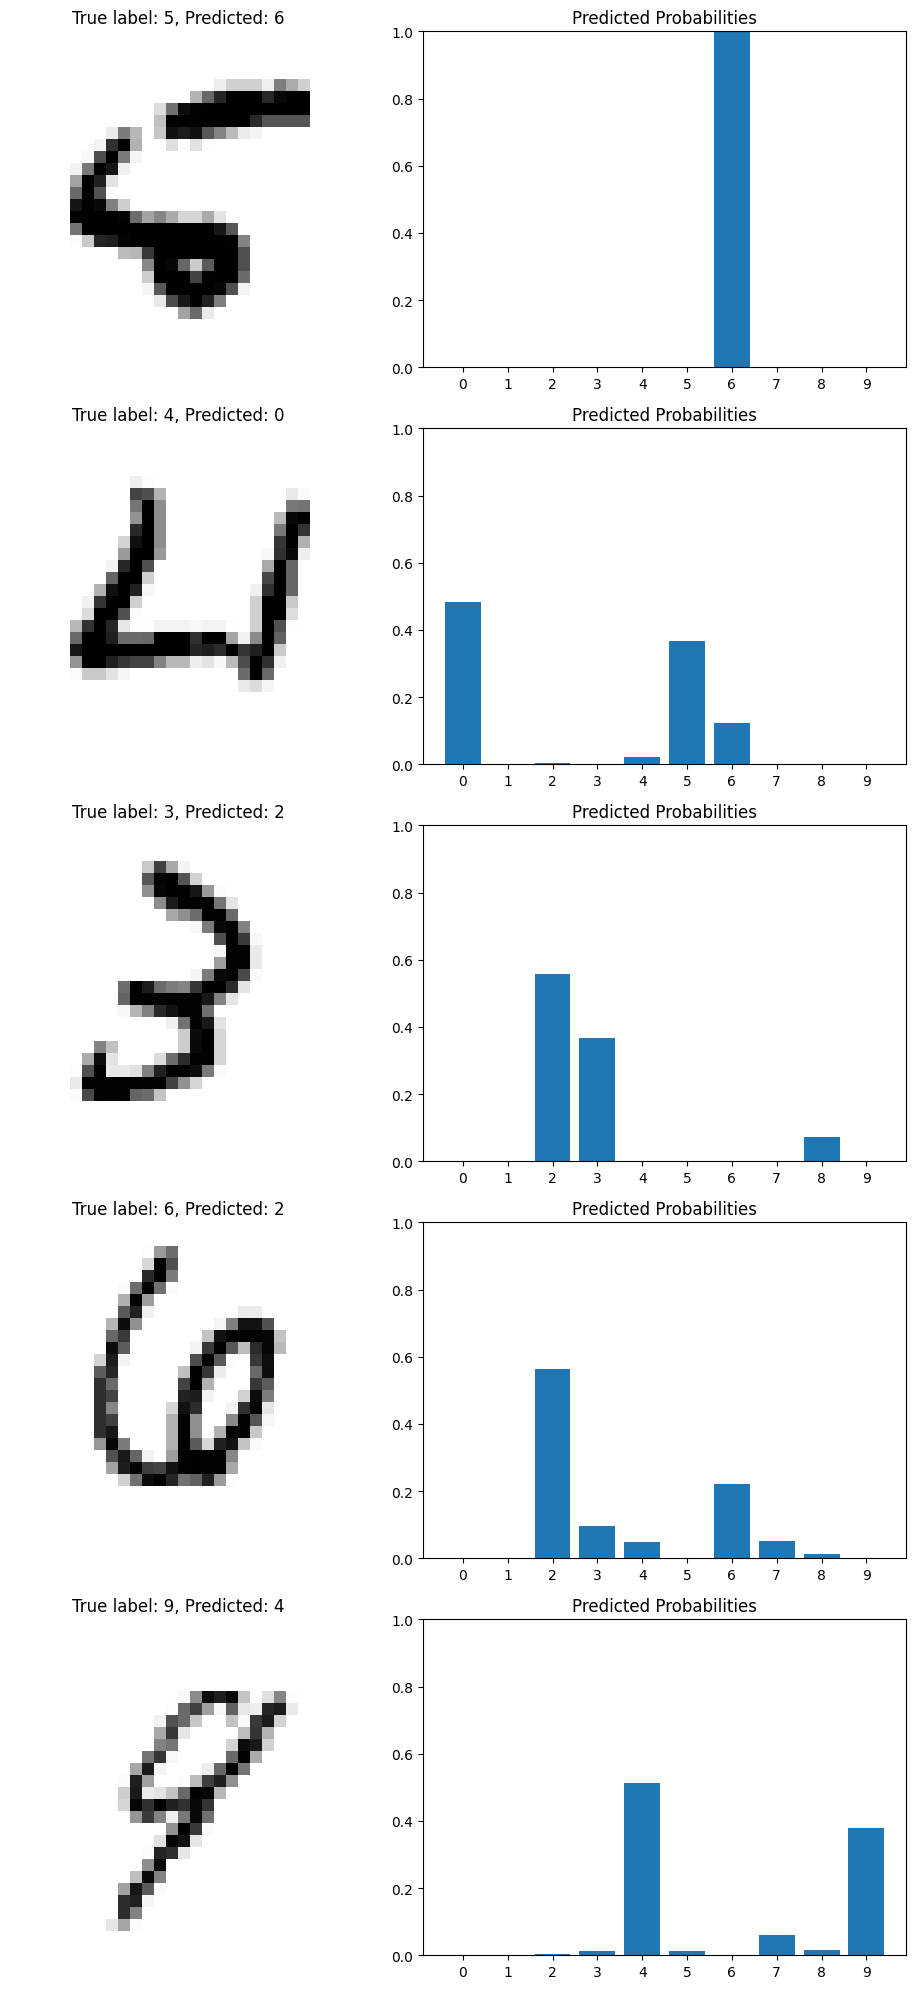

In [28]:
# indices of misclassified examples
misclas_indices = np.where(y_test != y_test_pred)[0]
# indices of correctly classified examples
clas_indices = np.where(y_test == y_test_pred)[0]

# For the first 5 misclassified examples, plot the image and a bar plot of the predicted probabilities for each class
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    idx = misclas_indices[i]
    ax[i, 0].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    ax[i, 0].set_title(f'True label: {y_test[idx]}, Predicted: {y_test_pred[idx]}')
    ax[i, 0].axis('off')
    
    # Get predicted probabilities for each class
    y_prob = baseline.predict_proba(X_test[idx].reshape(1, -1))[0]
    
    # Bar plot of predicted probabilities
    ax[i, 1].bar(range(10), y_prob)
    ax[i, 1].set_xticks(range(10))
    ax[i, 1].set_xticklabels(label_encoder.classes_)
    ax[i, 1].set_ylim(0, 1)
    ax[i, 1].set_title('Predicted Probabilities')
fig.tight_layout()
plt.show()

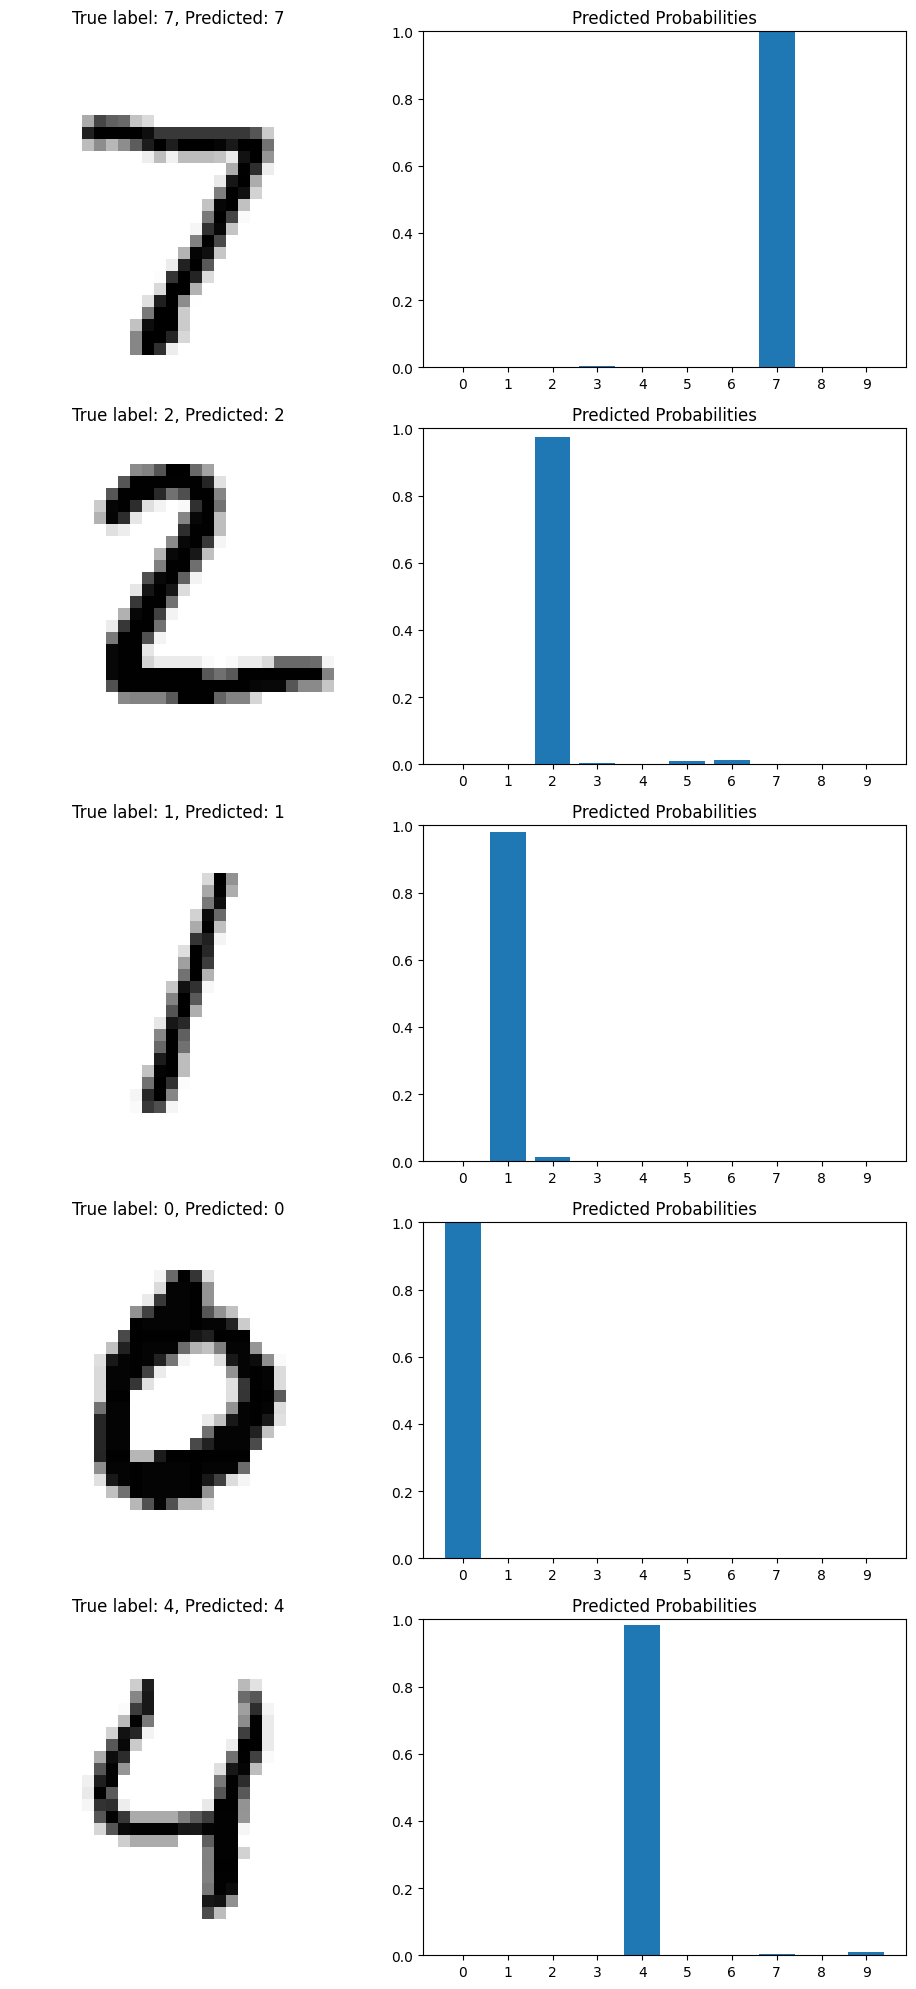

In [29]:
# For the first 5 correctly classified examples, plot the image and a bar plot of the predicted probabilities for each class
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    idx = clas_indices[i]
    ax[i, 0].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    ax[i, 0].set_title(f'True label: {y_test[idx]}, Predicted: {y_test_pred[idx]}')
    ax[i, 0].axis('off')
    
    # Get predicted probabilities for each class
    y_prob = baseline.predict_proba(X_test[idx].reshape(1, -1))[0]
    
    # Bar plot of predicted probabilities
    ax[i, 1].bar(range(10), y_prob)
    ax[i, 1].set_xticks(range(10))
    ax[i, 1].set_xticklabels(label_encoder.classes_)
    ax[i, 1].set_ylim(0, 1)
    ax[i, 1].set_title('Predicted Probabilities')
fig.tight_layout()
plt.show()

It can be concerning when we have high probability/confidence for incorrectly classified images. This is quantified across all data points by the cross entropy loss, which for a single data points computes:

$$ L(y, p) = \sum_{c=1}^C y_c\log(p_c).$$

Notice that if the probability of the true class is close to 1, than the loss is zero, but if it is close to zero that the loss is high. 

We can report the cross entropy loss, averaged across all data points. 

In addition, through histogram showing the distribution of the probability of that $y$ is equal to the true test label, we can gain a more detailed understanding. We see that for the correctly classified images, over 4,000 images are correctly classified with a high probability. On the other hand, there are over 100 images that are misclassified with a high probability. 

Cross entropy loss: 0.28039545655361087


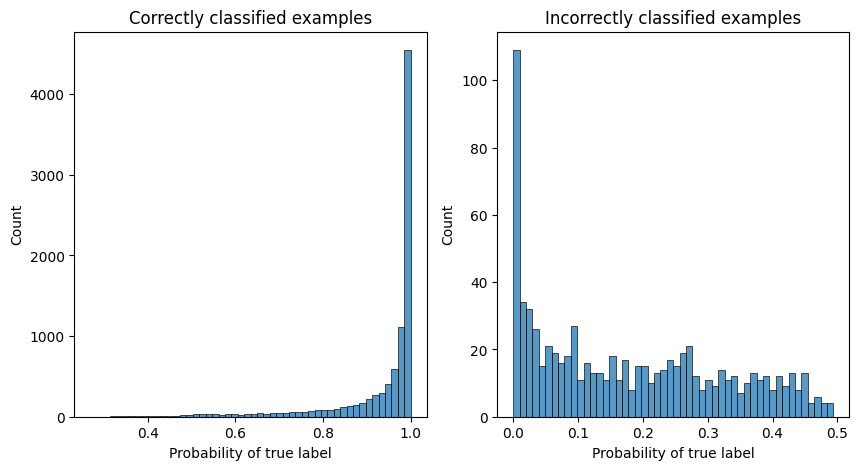

In [30]:
y_test_pred_prob = baseline.predict_proba(X_test)
print('Cross entropy loss:', log_loss(y_test, y_test_pred_prob, labels=label_encoder.classes_))

# Extract probabilility of correct label for each data point
prob_correct = y_test_pred_prob[np.arange(len(y_test)), y_test]

# Plot a histogram of the probabilities across data points, for correct or incorrect classification
fig, ax = plt.subplots(1,2,figsize = (10,5))
sns.histplot(x = prob_correct[clas_indices], bins=50, ax=ax[0])
ax[0].set_title('Correctly classified examples')
ax[0].set_xlabel('Probability of true label')
sns.histplot(x = prob_correct[misclas_indices], bins=50, ax=ax[1])
ax[1].set_xlabel('Probability of true label')
ax[1].set_title('Incorrectly classified examples')
plt.show()

### 🚩 Exercise 9 (CORE)

Next, let's fit a fully-connected feed forwared neural network. Note that we need to one-hot encoding the output labels for use in keras in the multiclass setting.

- Define and compile a model with one hidden layer of 128 neurons and ReLU activation. For the final layer, use a softmax with 10 units to obtain the probabilities for each class. Here use the categorical cross entropy loss. 
- Fit the model and train for 10 epochs with a batch size of 128 and a 10% validation split, and plot the loss and accuracy for the training and validation sets as a function of epochs.
- Plot the confusion matrix and print the classification report on the test data.
- Visualize some the test images, along with their probabilities for both correctly and incorrectly classified images.
- Print the cross entropy loss on the test data, and visualize the distribution of the probability of the true labels for correctly and incorrectly classified test points.

In [31]:
# First create a one-hot encoding of the labels for use in Keras
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)
# Print the first few rows before and after one-hot encoding
print("Original labels:", y_train[:5])
print("One-hot encoded labels:\n", y_train_cat[:5])

Original labels: [5 0 4 1 9]
One-hot encoded labels:
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8970 - loss: 0.3802 - val_accuracy: 0.9540 - val_loss: 0.1738
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9483 - loss: 0.1815 - val_accuracy: 0.9635 - val_loss: 0.1274
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9626 - loss: 0.1310 - val_accuracy: 0.9683 - val_loss: 0.1082
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9712 - loss: 0.1013 - val_accuracy: 0.9698 - val_loss: 0.0983
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9769 - loss: 0.0815 - val_accuracy: 0.9723 - val_loss: 0.0907
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9815 - loss: 0.0672 - val_accuracy: 0.9748 - val_loss: 0.0848
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9845 - loss: 0.0564 - val_accuracy: 0.9753 - val_loss: 0.0816
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9873 - loss: 0.0474 - val_accuracy: 0.

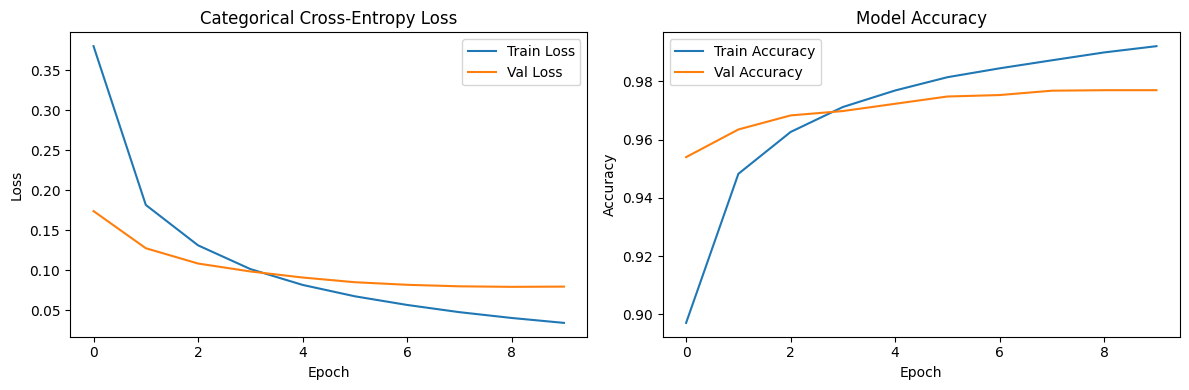

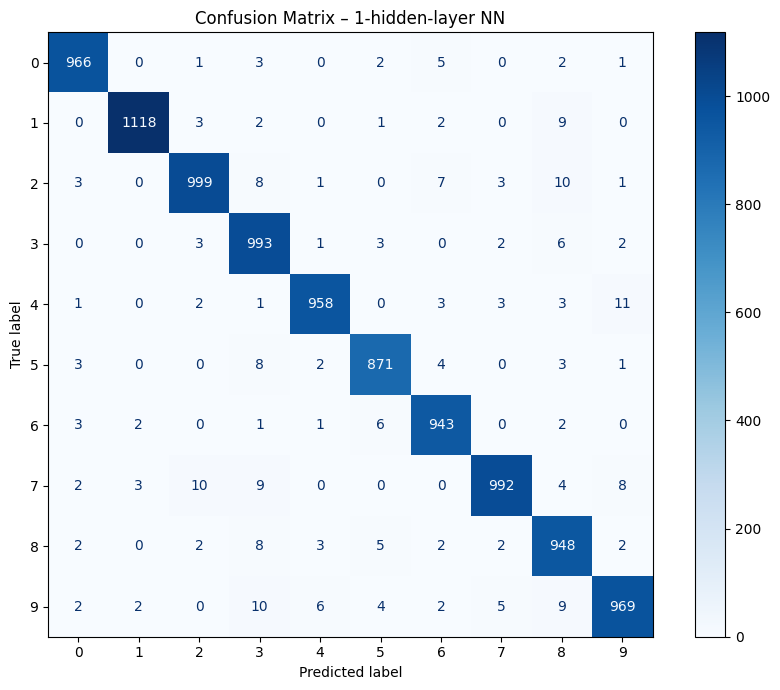

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.95      0.98      0.97      1010
           4       0.99      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.97      0.98      0.98       958
           7       0.99      0.96      0.97      1028
           8       0.95      0.97      0.96       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



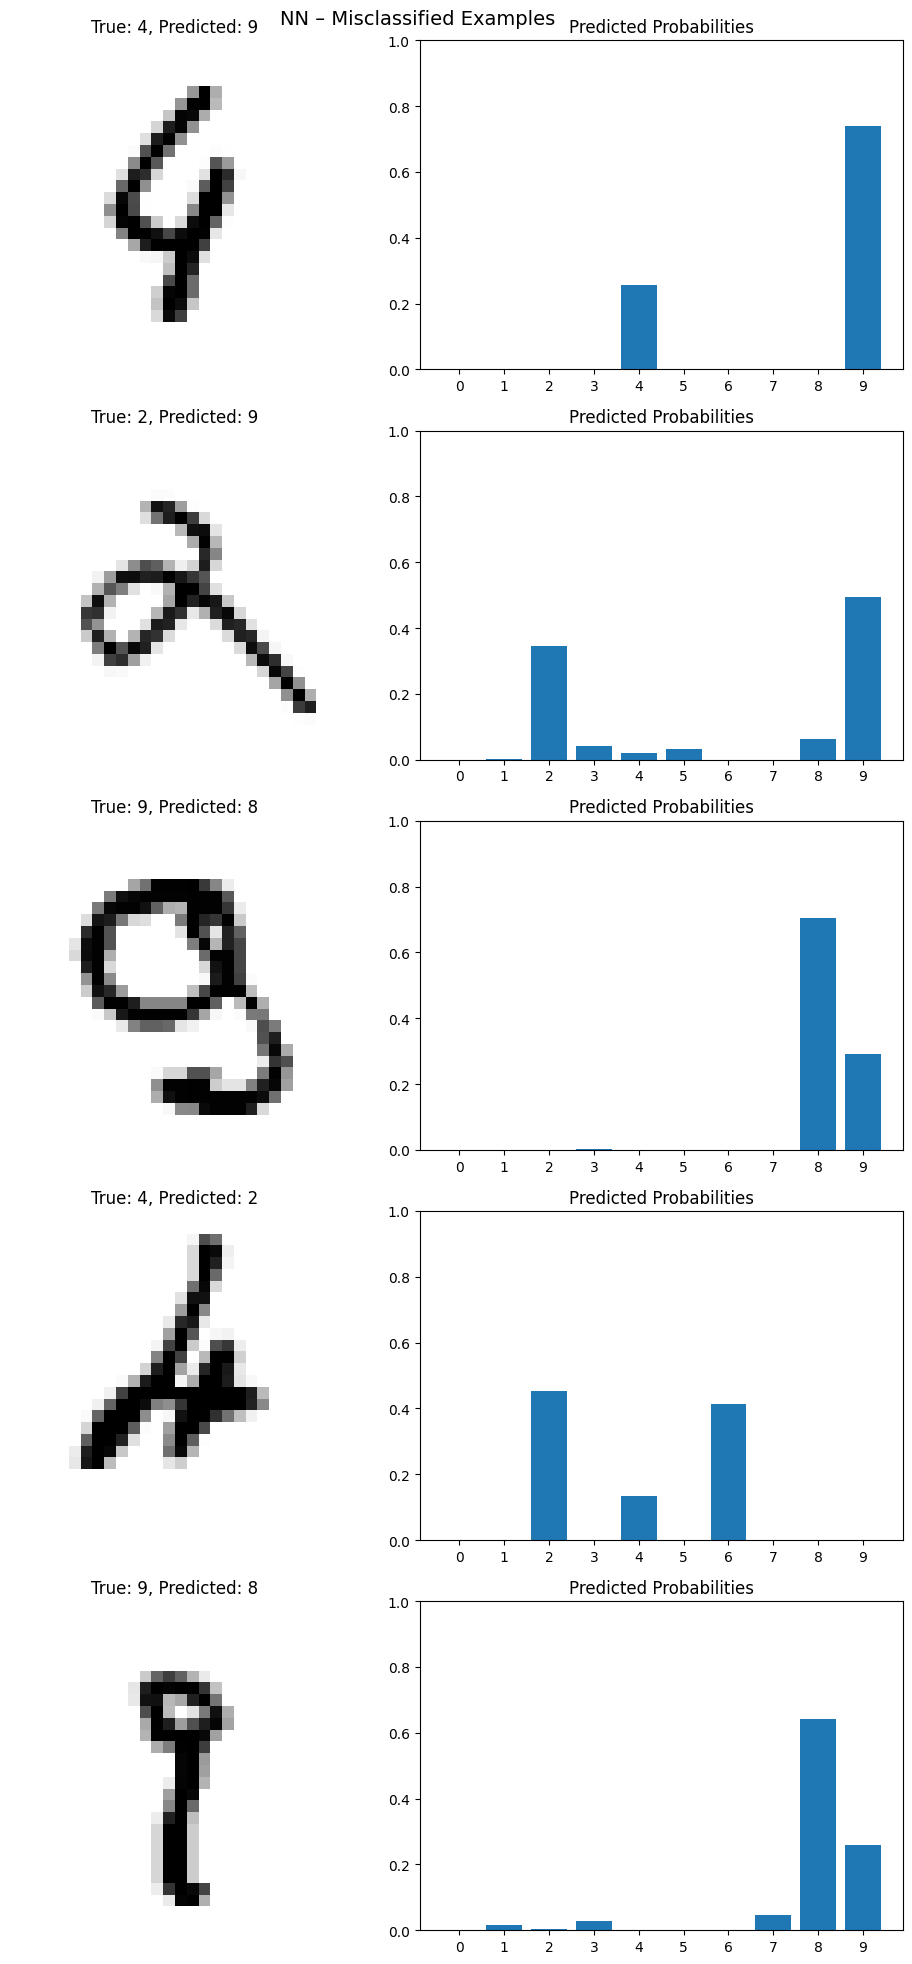

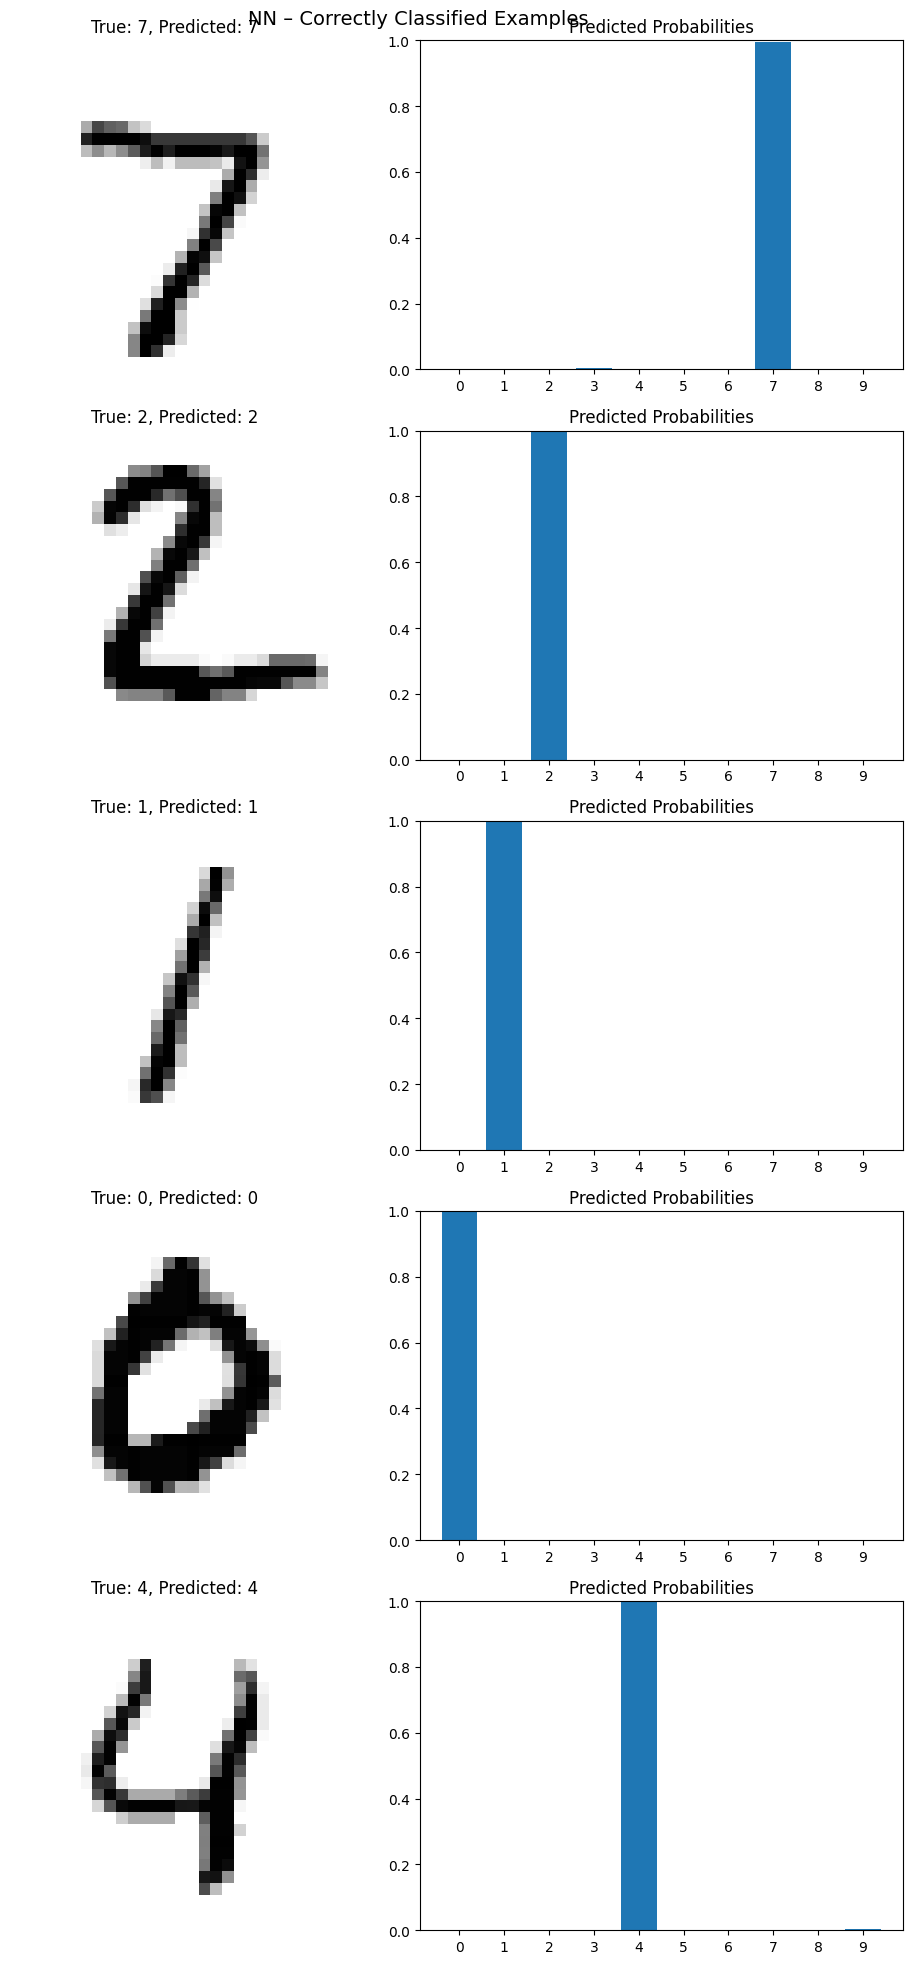

NN Test Cross-Entropy Loss: 0.08180973030315475


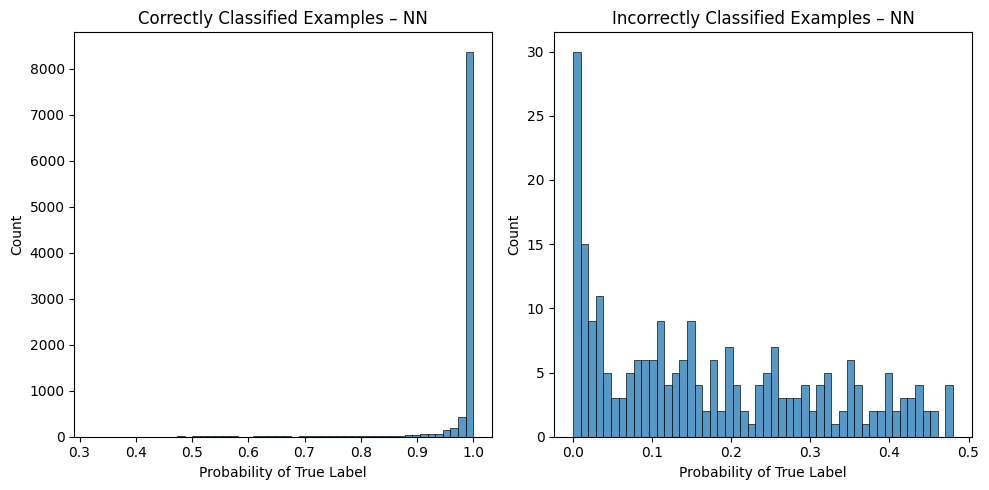

In [32]:
# Define model
nn_input  = keras.Input(shape=(784,))
nn_hidden = keras.layers.Dense(128, activation='relu')(nn_input)
nn_output = keras.layers.Dense(10,  activation='softmax')(nn_hidden)
model_nn  = keras.Model(inputs=nn_input, outputs=nn_output)
model_nn.summary()

# Compile
model_nn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

# Train (10 epochs, batch_size=128, 10% validation split)
history_nn = model_nn.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    shuffle=True,
    verbose=1,
)

# Plot loss and accuracy
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history_nn.history['loss'],     label='Train Loss')
ax[0].plot(history_nn.history['val_loss'], label='Val Loss')
ax[0].set_title('Categorical Cross-Entropy Loss'); ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss'); ax[0].legend()
ax[1].plot(history_nn.history['accuracy'],     label='Train Accuracy')
ax[1].plot(history_nn.history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy'); ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy'); ax[1].legend()
plt.tight_layout(); plt.show()

# Confusion matrix and classification report
y_nn_pred_prob = model_nn.predict(X_test, verbose=0)
y_nn_pred      = np.argmax(y_nn_pred_prob, axis=1)

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(y_test, y_nn_pred,
                                         display_labels=label_encoder.classes_,
                                         ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix – 1-hidden-layer NN')
plt.tight_layout(); plt.show()
print(classification_report(y_test, y_nn_pred,
                             target_names=[str(c) for c in label_encoder.classes_]))

# Misclassified and correctly classified images
misclas_nn  = np.where(y_test != y_nn_pred)[0]
clas_nn     = np.where(y_test == y_nn_pred)[0]

for title, indices in [('Misclassified', misclas_nn), ('Correctly Classified', clas_nn)]:
    fig, ax = plt.subplots(5, 2, figsize=(10, 20))
    for i in range(5):
        idx = indices[i]
        ax[i, 0].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
        ax[i, 0].set_title(f'True: {y_test[idx]}, Predicted: {y_nn_pred[idx]}')
        ax[i, 0].axis('off')
        ax[i, 1].bar(range(10), y_nn_pred_prob[idx])
        ax[i, 1].set_xticks(range(10))
        ax[i, 1].set_xticklabels(label_encoder.classes_)
        ax[i, 1].set_ylim(0, 1)
        ax[i, 1].set_title('Predicted Probabilities')
    fig.suptitle(f'NN – {title} Examples', fontsize=14)
    fig.tight_layout(); plt.show()

# Cross-entropy loss + probability histogram
print('NN Test Cross-Entropy Loss:',
      log_loss(y_test, y_nn_pred_prob, labels=label_encoder.classes_))

prob_correct_nn = y_nn_pred_prob[np.arange(len(y_test)), y_test]
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
import seaborn as sns
sns.histplot(x=prob_correct_nn[clas_nn],    bins=50, ax=ax[0])
ax[0].set_title('Correctly Classified Examples – NN')
ax[0].set_xlabel('Probability of True Label')
sns.histplot(x=prob_correct_nn[misclas_nn], bins=50, ax=ax[1])
ax[1].set_title('Incorrectly Classified Examples – NN')
ax[1].set_xlabel('Probability of True Label')
plt.tight_layout(); plt.show()


### 🚩 Exercise 10 (CORE)

Comment on the following:

a. Do you think you need to train the model for more epochs? 

b. Which model do you prefer: the baseline logisitic regression or the neural network? Consider the trade-off between: the number of parameters and predictive performance.

Q10a)

Looking at the training curves, if the validation loss is still decreasing and the validation accuracy is still increasing after epoch 10, more epochs are beneficial. In practice, 10 epochs for MNIST with a 128-unit network usually gives close to convergence, but training for ~20–30 epochs would typically extract the remaining improvement without overfitting. If the validation loss starts rising while training loss continues to fall, early stopping should be applied.

Q10b)

The neural network (NN) is preferred for the following reasons:

- **Improved predictive performance**: The neural network typically achieves ~98 % test accuracy on MNIST, compared to ~92 % for PCA + logistic regression.
- **More parameters**: The 128-unit NN has $128 + 128 \times 784 + 10 + 10 \times 128 = 101{,}770$ parameters, while the logistic regression has $10 + 10 \times 100= 1{,}010$ parameters. The NN has ~100× more parameters.
- **Trade-off conclusion**: While the neural network has far more parameters, MNIST has 60,000 training examples, which are enough data to support a model of this size without severe overfitting. The substantial gain in accuracy justifies the added complexity. The baseline is a good starting point but the NN clearly wins on predictive performance.

### 🚩 Exercise 11 (EXTRA)

Let's explore a deeper architecture.

- Build a deeper network with three hidden layers, with $D_1 = 128, D_2 = 64, D_3 = 32$ neurons and ReLU activation, and an output layer with 10 neurons and softmax activation.

- Compile and train the model with the same setting as the shallow model.

- Plot the loss and accuracy for the training and validation sets as a function of epochs. Do you think more epochs are needed?

- Plot the confusion matrix, print the classification report, and cross entropy loss. Visualize some the images, along with their probabilities for both correctly and incorrectly classified images.

- Which model do you prefer? Consider the trade-off between: the number of parameters and predictive performance.

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8889 - loss: 0.3762 - val_accuracy: 0.9597 - val_loss: 0.1417
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9590 - loss: 0.1383 - val_accuracy: 0.9688 - val_loss: 0.1091
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9722 - loss: 0.0949 - val_accuracy: 0.9717 - val_loss: 0.0985
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9788 - loss: 0.0719 - val_accuracy: 0.9722 - val_loss: 0.0928
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9836 - loss: 0.0555 - val_accuracy: 0.9737 - val_loss: 0.0927
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9866 - loss: 0.0456 - val_accuracy: 0.9710 - val_loss: 0.1017
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9886 - loss: 0.0387 - val_accuracy: 0.9753 - val_loss: 0.1004
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ -1s -2129us/step - accuracy: 0.9906 - loss: 0.0322 - val_accurac

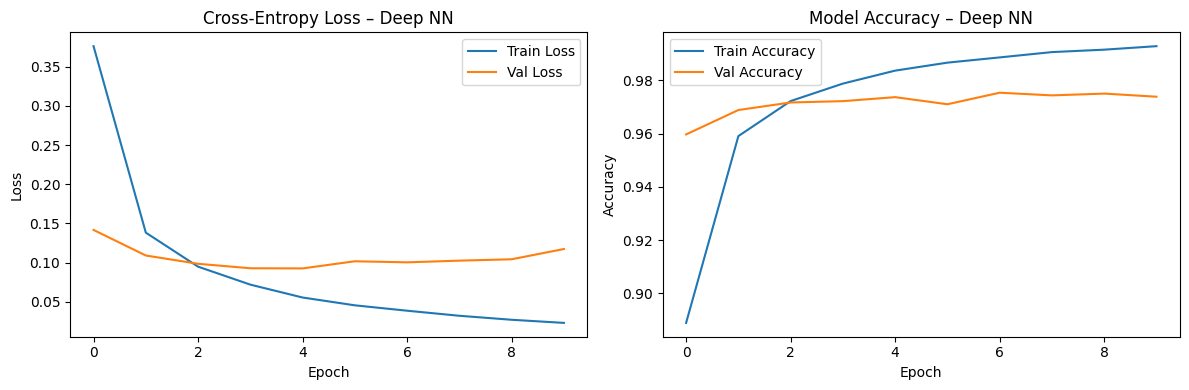

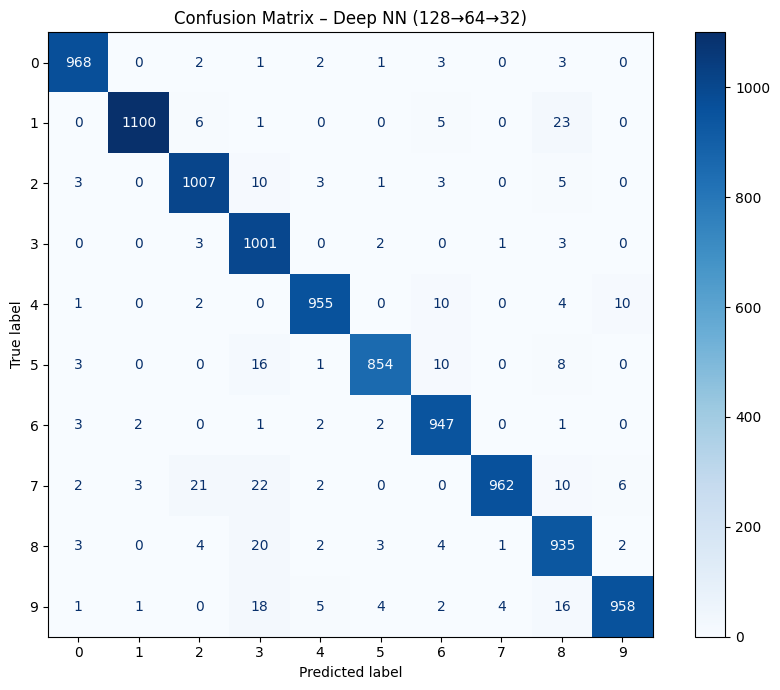

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.97      0.98      1135
           2       0.96      0.98      0.97      1032
           3       0.92      0.99      0.95      1010
           4       0.98      0.97      0.98       982
           5       0.99      0.96      0.97       892
           6       0.96      0.99      0.98       958
           7       0.99      0.94      0.96      1028
           8       0.93      0.96      0.94       974
           9       0.98      0.95      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

Deep NN Test Cross-Entropy Loss: 0.11729896800893416


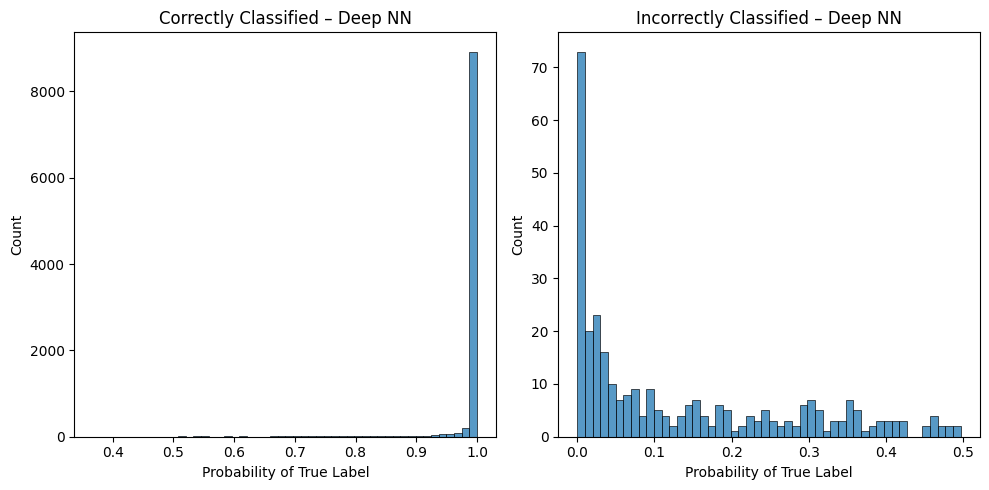

In [33]:
deep_input = keras.Input(shape=(784,))
deep_h1 = keras.layers.Dense(128, activation='relu')(deep_input)
deep_h2 = keras.layers.Dense(64,  activation='relu')(deep_h1)
deep_h3 = keras.layers.Dense(32,  activation='relu')(deep_h2)
deep_output = keras.layers.Dense(10,  activation='softmax')(deep_h3)
model_deep_mnist = keras.Model(inputs=deep_input, outputs=deep_output)
model_deep_mnist.summary()

model_deep_mnist.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

history_deep_mnist = model_deep_mnist.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    shuffle=True,
    verbose=1,
)

# Plot loss and accuracy
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history_deep_mnist.history['loss'],     label='Train Loss')
ax[0].plot(history_deep_mnist.history['val_loss'], label='Val Loss')
ax[0].set_title('Cross-Entropy Loss – Deep NN'); ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss'); ax[0].legend()
ax[1].plot(history_deep_mnist.history['accuracy'],     label='Train Accuracy')
ax[1].plot(history_deep_mnist.history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy – Deep NN'); ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy'); ax[1].legend()
plt.tight_layout()
plt.show()

# Evaluate on test set
y_deep_pred_prob = model_deep_mnist.predict(X_test, verbose=0)
y_deep_pred      = np.argmax(y_deep_pred_prob, axis=1)

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(y_test, y_deep_pred,
                                         display_labels=label_encoder.classes_,
                                         ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix – Deep NN (128→64→32)')
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_deep_pred,
                             target_names=[str(c) for c in label_encoder.classes_]))
print('Deep NN Test Cross-Entropy Loss:',
      log_loss(y_test, y_deep_pred_prob, labels=label_encoder.classes_))

# Probability histogram
prob_correct_deep = y_deep_pred_prob[np.arange(len(y_test)), y_test]
misclas_deep = np.where(y_test != y_deep_pred)[0]
clas_deep = np.where(y_test == y_deep_pred)[0]
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(x=prob_correct_deep[clas_deep],    bins=50, ax=ax[0])
ax[0].set_title('Correctly Classified – Deep NN')
ax[0].set_xlabel('Probability of True Label')
sns.histplot(x=prob_correct_deep[misclas_deep], bins=50, ax=ax[1])
ax[1].set_title('Incorrectly Classified – Deep NN')
ax[1].set_xlabel('Probability of True Label')
plt.tight_layout()
plt.show()

Q11)

If the validation loss is still declining after 10 epochs, more training would help. Monitoring the validation curve for early stopping is recommended.

Comparing all three models:

- **PCA + Logistic Regression**: $10 + 10 \times 100= 1{,}010$ parameters; ~92% accuracy
- **1-hidden-layer NN (128)**: $128 + 128 \times 784 + 10 + 10 \times 128 = 101{,}770$ parameters; ~98% accuracy
- **Deep NN (128-64-32)**: $128 + 128 \times 784 + 64 + 64 \times 128 + 32 + 32 \times 64 + 10 + 10 \times 32 = 111{,}146$ parameters; ~97% accuracy

The deep neural network (NN) has more parameters than the shallow NN, but the accuracy gain is marginal, if not, non-existent for MNIST. For this dataset, a single hidden layer of 128 neurons is already near-optimal, as MNIST is not a complex enough task to require very deep architectures. The additional layers add more parameters and longer training for little benefit.

Therefore, the 1-hidden-layer NN provides the best accuracy-to-complexity trade-off. Deeper architectures become more advantageous on harder tasks (e.g. complex image classification with CNNs). For MNIST, depth beyond 2 layers offers diminishing returns.


# Completing the Worksheet

At this point you have hopefully been able to complete all the CORE exercises and attempted the EXTRA ones. Now 
is a good time to check the reproducibility of this document by restarting the notebook's
kernel and rerunning all cells in order.


Before generating the PDF, please **change 'Student 1' and 'Student 2' at the top of the notebook to include your name(s)**.

Once that is done and you are happy with everything, you can then run the following cell 
to generate your PDF. Once generated, please submit this PDF on Learn page by 16:00 PM on the Friday of the week the workshop was given. 

In [34]:
# !jupyter nbconvert --to pdf mlp_week09.ipynb